# Notebook 1 — Apprentissage Supervisé
## Optimisation Énergétique des Réseaux BTS — Tunisie Telecom
**Projet de Fin d'Études | ISIMA × Tunisie Telecom | 2025–2026**

---

### Structure CRISP-DM de ce notebook
| Phase | Contenu |
|---|---|
| 1 | Compréhension métier & chargement des données |
| 2 | Préparation, nettoyage & feature engineering |
| 3 | Analyse exploratoire (EDA) |
| 4 | Comparaison de 7 modèles supervisés |
| 5 | Validation croisée temporelle |
| 6 | Évaluation finale & interprétabilité SHAP |

**Sorties produites :**
- `outputs/modele_lgbm.joblib` — LightGBM 
- `outputs/encodeurs.joblib` — encodeurs catégoriels
- `outputs/quantile_models.joblib` — modèles Q10/Q90
- `outputs/df_train_processed.parquet`  — données d'entraînement enrichies
- `outputs/df_test_processed.parquet`   — données de test enrichies avec prédictions
- `outputs/df_full_processed.parquet`   — dataset complet (train + test) avec toutes les features et colonnes QoS
- `outputs/best_model.joblib` — meilleur modèle retenu (LGBMRegressor)
- `outputs/resultats_modeles.json` — tableau comparatif des 7 modèles


In [4]:
# Cellule 0 — Imports & configuration globale
import warnings
warnings.filterwarnings('ignore')
import os
import random
import numpy as np

# Reproducibility
os.environ['PYTHONHASHSEED'] = '42'

random.seed(42)
np.random.seed(42)
import subprocess, sys
import os, json, time
import numpy  as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Machine Learning — Supervisé
from sklearn.linear_model     import LinearRegression, Ridge
from sklearn.ensemble         import (RandomForestRegressor,
                                       GradientBoostingRegressor,
                                       ExtraTreesRegressor)
from sklearn.preprocessing    import LabelEncoder
from sklearn.model_selection  import TimeSeriesSplit
from sklearn.metrics          import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute            import SimpleImputer

import joblib

try:
    import lightgbm as lgb
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb
    HAS_XGB = True

try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

# Dossier de sortie
os.makedirs('outputs', exist_ok=True)

# Style graphiques
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print('Imports terminés')
print(f'   LightGBM {lgb.__version__} | XGBoost {xgb.__version__}')


Imports terminés
   LightGBM 4.6.0 | XGBoost 3.2.0


---
## Phase 1 — Compréhension Métier & Chargement des Données

### Contexte
Tunisie Telecom exploite des centaines de stations de base (BTS/eNB). Chaque station
consomme de l'électricité en continu. Ce projet vise à :
- **Prédire** la consommation horaire de chaque station via ML supervisé
- **Détecter** les anomalies de consommation (notebook 2)
- **Optimiser** les modes de fonctionnement via un moteur de décision (notebook 3)

### KPI cibles
| KPI | Objectif |
|---|---|
| R² du modèle | ≥ 0.80 |
| RMSE relative | ≤ 20 % |
| Économie simulée | ≥ 10 % |


In [5]:
# Cellule 1 — Chargement des données

# Le fichier enrichi contient 6 colonnes météo supplémentaires
# (humidite_relative_pct, vitesse_vent_ms, rayonnement_solaire_wm2,
# precipitation_mmh, pression_atmospherique_hpa, indice_uv).
# La compression xz (LZMA2) est lue nativement par pandas.
DATA_PATH = "/kaggle/input/datasets/benhadjalayamolka/dataset-3ans/tunisie_telecom_dataset.csv"
df_raw = pd.read_csv(DATA_PATH)
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], errors="coerce")

print(f'Dataset chargé : {df_raw.shape}')
print(f'  Stations      : {df_raw["station_id"].nunique()}')
print(f'  Période       : {df_raw["timestamp"].min().date()} -> {df_raw["timestamp"].max().date()}')

print('\nRépartition par année :')
for an, grp in df_raw.groupby('annee'):
    role = 'TRAIN' if an < 2024 else 'TEST'
    print(f'  {an} [{role}] : {len(grp):>10,} lignes')

df_raw.head(5)


Dataset chargé : (1787239, 29)
  Stations      : 72
  Période       : 2022-01-01 -> 2024-12-31

Répartition par année :
  0 [TRAIN] :      1,886 lignes
  1900 [TRAIN] :      1,757 lignes
  2022 [TRAIN] :    593,319 lignes
  2023 [TRAIN] :    593,302 lignes
  2024 [TEST] :    593,469 lignes
  2030 [TEST] :      1,753 lignes
  9999 [TEST] :      1,753 lignes


,timestamp,annee,station_id,gouvernorat,type_zone,technologie,latitude,longitude,heure,jour_semaine,...,charge_cpu_pct,nb_secteurs_actifs,puissance_emission_dbm,consommation_kwh,humidite_relative_pct,vitesse_vent_ms,rayonnement_solaire_wm2,precipitation_mmh,pression_atmospherique_hpa,indice_uv
0,2022-01-01 00:00:00,2022,TT-SFA-001,Sfax,Urbain,2G,34.8792,10.8192,0,5,...,1.0,2,32.7,0.761,74.6,4.09,0.0,0.00,1014.3,0.0
1,2022-01-01 01:00:00,2022,TT-SFA-001,Sfax,Urbain,2G,34.8792,10.8192,1,5,...,5.1,2,33.6,0.948,76.0,4.42,0.0,0.00,1017.5,0.0
2,2022-01-01 02:00:00,2022,TT-SFA-001,Sfax,Urbain,2G,34.8792,10.8192,2,5,...,10.3,2,32.0,0.912,75.2,4.63,0.0,0.76,1016.4,0.0
3,2022-01-01 03:00:00,2022,TT-SFA-001,Sfax,Urbain,2G,34.8792,10.8192,3,5,...,4.5,2,33.1,0.845,72.2,2.82,0.0,0.00,1015.2,0.0
4,2022-01-01 04:00:00,2022,TT-SFA-001,Sfax,Urbain,2G,34.8792,10.8192,4,5,...,2.9,2,32.4,0.966,77.4,3.61,0.0,0.00,1018.2,0.0


---
## Phase 1b — Data Cleaning

> **Objectif :** détecter et corriger toutes les anomalies injectées dans le dataset
> avant d'entrer dans le pipeline de prétraitement ML (Phase 2).
> Chaque cellule traite un type d'anomalie spécifique et documente les corrections.
>
> | Cellule | Anomalie traitée |
> |---------|------------------|
> | DC-1 | Diagnostic initial — inventaire complet des anomalies |
> | DC-2 | Doublons exacts + timestamps invalides / hors plage |
> | DC-3 | Catégorielles aberrantes (gouvernorat, technologie, type_zone, station_id) |
> | DC-4 | Numériques : textes dans colonnes numériques + bornes physiques |
> | DC-5 | Capteurs figés (valeur constante répétée ≥ 20 fois) |
> | DC-6 | Imputation des NaN résiduels (médiane contextuelle, anti-leakage) |
> | DC-7 | Bilan chiffré + visualisation avant/après + mise à jour df_raw |


In [6]:
# CELLULE DC-1 — DIAGNOSTIC INITIAL : ÉTAT DES ANOMALIES AVANT NETTOYAGE
# Objectif : quantifier chaque type d'anomalie présente dans df_raw
#   avant tout traitement, pour justifier chaque étape de nettoyage.
# Types détectés :
#   1. Valeurs manquantes (NaN)
#   2. Doublons exacts
#   3. Formats timestamp invalides
#   4. Valeurs aberrantes dans colonnes catégorielles
#   5. Valeurs physiquement impossibles dans colonnes numériques
#   6. Incohérences logiques entre colonnes
#   7. Capteurs figés (valeur constante répétée)
#   8. Coordonnées GPS hors territoire tunisien

print('  DIAGNOSTIC INITIAL DES ANOMALIES — df_raw')

# 1. Dimensions
print(f'\nDimensions brutes : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')

#  2. Valeurs manquantes (NaN)
print('\n[1] VALEURS MANQUANTES (NaN) :')
nan_counts = df_raw.isnull().sum()
nan_pct    = nan_counts / len(df_raw) * 100
nan_report = pd.DataFrame({'nb_nan': nan_counts, 'pct_nan': nan_pct.round(2)})
nan_report = nan_report[nan_report['nb_nan'] > 0].sort_values('nb_nan', ascending=False)
if nan_report.empty:
    print('  Aucune valeur manquante détectée.')
else:
    for col, row in nan_report.iterrows():
        print(f'  {col:<35} : {int(row.nb_nan):>10,} NaN ({row.pct_nan:5.2f}%)')

# 3. Doublons exacts
print('\n[2] DOUBLONS EXACTS :')
n_dup = df_raw.duplicated().sum()
print(f'  Lignes dupliquées : {n_dup:,} ({n_dup/len(df_raw)*100:.2f}%)')

#  4. Timestamps invalides
print('\n[3] TIMESTAMPS INVALIDES :')
# On tente la conversion — les valeurs non parsables deviennent NaT
ts_test    = pd.to_datetime(df_raw['timestamp'], errors='coerce')
n_ts_bad   = ts_test.isnull().sum()
n_ts_futur = (ts_test > pd.Timestamp('2025-01-01')).sum()
n_ts_past  = (ts_test < pd.Timestamp('2020-01-01')).sum()
print(f'  Non parsables (format inconnu)  : {n_ts_bad:,}')
print(f'  Postérieurs au 01/01/2025       : {n_ts_futur:,}')
print(f'  Antérieurs au 01/01/2020        : {n_ts_past:,}')

#  5. Valeurs aberrantes catégorielles
print('\n[4] VALEURS ABERRANTES — COLONNES CATÉGORIELLES :')
valeurs_valides = {
    'technologie' : {'2G', '3G', '4G', '4G+'},
    'type_zone'   : {'Urbain', 'Periurbain', 'Rural'},
    'gouvernorat' : {
        'Tunis','Ariana','Ben Arous','Manouba','Nabeul','Zaghouan','Bizerte',
        'Beja','Jendouba','Le Kef','Siliana','Kairouan','Kasserine','Sidi Bouzid',
        'Sousse','Monastir','Mahdia','Sfax','Gafsa','Tozeur','Kebili',
        'Gabes','Medenine','Tataouine'
    },
}
for col, valides in valeurs_valides.items():
    invalides = df_raw[col].dropna()[~df_raw[col].dropna().isin(valides)]
    if len(invalides) > 0:
        print(f'  {col:<15} : {len(invalides):>10,} valeurs invalides')
        print(f'               Exemples : {list(invalides.value_counts().head(5).index)}')
    else:
        print(f'  {col:<15} : OK — toutes les valeurs sont dans le référentiel')

# Format station_id
import re
pattern_station = re.compile(r'^TT-[A-Z]{2,3}-\d{3}$')
bad_station = df_raw['station_id'].dropna()[~df_raw['station_id'].dropna().str.match(r'^TT-[A-Z]{2,3}-\d{3}$')]
print(f'  {"station_id":<15} : {len(bad_station):>10,} formats invalides')
if len(bad_station) > 0:
    print(f'               Exemples : {list(bad_station.value_counts().head(5).index)}')

#  6. Outliers numériques physiquement impossibles ─
print('\n[5] VALEURS PHYSIQUEMENT IMPOSSIBLES :')
bornes_physiques = {
    'temperature_ambiante'         : (-15.0,  55.0,  'Hors plage Tunisie [-15, 55]°C'),
    'charge_cpu_pct'               : (  0.0, 100.0,  'CPU hors [0, 100]%'),
    'humidite_relative_pct'        : (  0.0, 100.0,  'Humidité hors [0, 100]%'),
    'trafic_voix_erlang'           : (  0.0, 500.0,  'Trafic voix négatif ou > 500 Erlang'),
    'trafic_data_mbps'             : (  0.0, 5000.0, 'Trafic data négatif ou > 5000 Mbps'),
    'nb_utilisateurs_actifs'       : (  0.0, 50000.0,'Utilisateurs négatifs ou > 50 000'),
    'puissance_emission_dbm'       : ( 20.0,  60.0,  'Puissance hors [20, 60] dBm'),
    'consommation_kwh'             : (  0.0, 100.0,  'Consommation négative ou > 100 kWh'),
    'vitesse_vent_ms'              : (  0.0, 113.0,  'Vent négatif ou > 113 m/s (record)'),
    'rayonnement_solaire_wm2'      : (  0.0, 1400.0, 'Rayonnement négatif ou > 1400 W/m²'),
    'precipitation_mmh'            : (  0.0, 200.0,  'Précipitations négatives'),
    'pression_atmospherique_hpa'   : (870.0, 1085.0, 'Pression hors [870, 1085] hPa'),
    'indice_uv'                    : (  0.0,  16.0,  'UV négatif ou > 16'),
}
total_outliers = 0
for col, (lo, hi, desc) in bornes_physiques.items():
    serie = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    n_bad = ((serie < lo) | (serie > hi)).sum()
    total_outliers += n_bad
    flag = ' ⚠' if n_bad > 0 else ' ✓'
    print(f'  {flag} {col:<35} : {n_bad:>8,} ({desc})')
print(f'  Total outliers physiques : {total_outliers:,}')

#  7. Incohérences logiques ─
print('\n[6] INCOHÉRENCES LOGIQUES :')
df_num = df_raw.copy()
for c in ['heure','mois','jour_semaine','est_weekend','est_vendredi']:
    df_num[c] = pd.to_numeric(df_num[c], errors='coerce')

# est_weekend=1 mais jour_semaine ∉ {5, 6} (sam=5, dim=6)
n_wkd = ((df_num['est_weekend'] == 1) & (~df_num['jour_semaine'].isin([5, 6]))).sum()
# est_vendredi=1 mais jour_semaine ≠ 4
n_ven = ((df_num['est_vendredi'] == 1) & (df_num['jour_semaine'] != 4)).sum()
# heure hors [0, 23]
n_h   = ((df_num['heure'] < 0) | (df_num['heure'] > 23)).sum()
# mois hors [1, 12]
n_m   = ((df_num['mois'] < 1)  | (df_num['mois'] > 12)).sum()
# nb_secteurs_actifs = 0 alors que trafic_data > 0
nb_s  = pd.to_numeric(df_raw.get('nb_secteurs_actifs', pd.Series(dtype=float)), errors='coerce')
td_s  = pd.to_numeric(df_raw.get('trafic_data_mbps',   pd.Series(dtype=float)), errors='coerce')
n_sec = ((nb_s == 0) & (td_s > 0)).sum()
print(f'  est_weekend=1 mais jour_semaine ∉ {{5,6}}  : {n_wkd:,}')
print(f'  est_vendredi=1 mais jour_semaine ≠ 4      : {n_ven:,}')
print(f'  Heure hors [0, 23]                        : {n_h:,}')
print(f'  Mois hors [1, 12]                         : {n_m:,}')
print(f'  nb_secteurs=0 avec trafic_data > 0        : {n_sec:,}')

#  8. Capteurs figés (valeur constante sur plusieurs lignes consécutives) ─
print('\n[7] CAPTEURS FIGÉS (même valeur répétée ≥ 20 fois consécutives) :')
cols_capteur = [
    'charge_cpu_pct', 'trafic_voix_erlang', 'trafic_data_mbps',
    'temperature_ambiante', 'puissance_emission_dbm',   # ← +2 colonnes alignées avec DC-5
]
stations_figees = set()
for col in cols_capteur:
    serie_num = pd.to_numeric(df_raw[col], errors='coerce')
    # Grouper par station_id et chercher les runs de valeurs identiques
    for st, grp in df_raw.groupby('station_id'):
        s = serie_num.loc[grp.index]
        run_max = s.groupby((s != s.shift()).cumsum()).transform('count').max()
        if run_max >= 20:
            stations_figees.add(st)
if stations_figees:
    print(f'  Stations avec capteur figé détecté : {len(stations_figees)}')
    for st in list(stations_figees)[:5]:
        print(f'    → {st}')
else:
    print('  Aucun capteur figé détecté.')

#  9. Coordonnées GPS hors Tunisie
print('\n[8] COORDONNÉES GPS HORS TUNISIE [30.2–37.5 N, 7.5–11.6 E] :')
n_lat = ((df_raw['latitude']  < 30.2) | (df_raw['latitude']  > 37.5)).sum()
n_lon = ((df_raw['longitude'] < 7.5)  | (df_raw['longitude'] > 11.6)).sum()
print(f'  Latitude  hors Tunisie : {n_lat:,}')
print(f'  Longitude hors Tunisie : {n_lon:,}')

print('  FIN DU DIAGNOSTIC — voir cellules DC-2 à DC-7 pour le nettoyage')


  DIAGNOSTIC INITIAL DES ANOMALIES — df_raw

Dimensions brutes : 1,787,239 lignes × 29 colonnes

[1] VALEURS MANQUANTES (NaN) :
  trafic_data_mbps                    :    155,306 NaN ( 8.69%)
  temperature_ambiante                :    137,730 NaN ( 7.71%)
  rayonnement_solaire_wm2             :    125,367 NaN ( 7.01%)
  vitesse_vent_ms                     :    106,920 NaN ( 5.98%)
  trafic_voix_erlang                  :    103,335 NaN ( 5.78%)
  nb_utilisateurs_actifs              :     89,744 NaN ( 5.02%)
  precipitation_mmh                   :     89,011 NaN ( 4.98%)
  charge_cpu_pct                      :     84,791 NaN ( 4.74%)
  humidite_relative_pct               :     80,694 NaN ( 4.52%)
  indice_uv                           :     71,810 NaN ( 4.02%)
  pression_atmospherique_hpa          :     71,614 NaN ( 4.01%)
  consommation_kwh                    :     71,411 NaN ( 4.00%)
  puissance_emission_dbm              :     44,555 NaN ( 2.49%)
  technologie                         : 

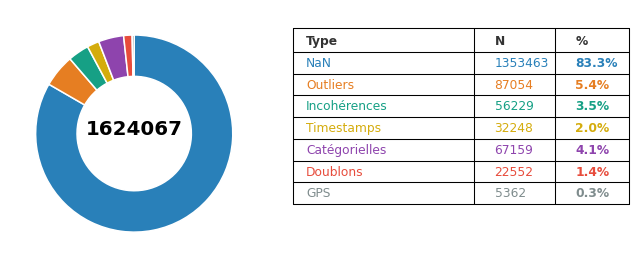

In [7]:
import matplotlib.pyplot as plt
import numpy as np

nan_total = nan_report['nb_nan'].sum() if not nan_report.empty else 0
n_outliers_num = total_outliers
n_incoherences = n_wkd + n_ven + n_h + n_m + n_sec
n_ts_invalid = n_ts_bad + n_ts_futur + n_ts_past
n_cat_bad = sum(
    len(df_raw[col].dropna()[~df_raw[col].dropna().isin(val)])
    for col, val in valeurs_valides.items()
) + len(bad_station)
n_dup_dc1 = n_dup
n_gps_bad = n_lat + n_lon

data_all = [
    ('NaN',          nan_total,       '#2980b9'),
    ('Outliers',     n_outliers_num,  '#e67e22'),
    ('Incohérences', n_incoherences,  '#16a085'),
    ('Timestamps',   n_ts_invalid,    '#d4ac0d'),
    ('Catégorielles',n_cat_bad,       '#8e44ad'),
    ('Doublons',     n_dup_dc1,       '#e74c3c'),
    ('GPS',          n_gps_bad,       '#7f8c8d'),
]

labels, counts, colors = zip(*data_all)
total = sum(counts)
pcts = [c / total * 100 for c in counts]

fig = plt.figure(figsize=(6, 2.8))
fig.patch.set_facecolor("white")
ax_donut = fig.add_axes([0.02, 0.15, 0.42, 0.80])
ax_table = fig.add_axes([0.47, 0.12, 0.51, 0.83])
ax_donut.set_aspect('equal')
ax_table.axis('off')
ax_table.set_xlim(0, 1)
ax_table.set_ylim(0, 1)

wedges, _ = ax_donut.pie(
    counts,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=1),
    counterclock=False
)
ax_donut.text(0, 0.05, str(total),
              ha='center', va='center',
              fontsize=13, fontweight='bold', color='black')
ax_donut.axis('off')

header_y  = 0.88
row_h     = 0.085
n_rows    = len(labels)
col_x     = [0.02, 0.58, 0.82]
col_sep   = [0.0, 0.54, 0.78, 1.0]

table_top    = header_y + row_h * 0.6
table_bottom = header_y - (n_rows + 0.5) * row_h

# toutes les lignes horizontales
all_y = [table_top, header_y - row_h * 0.5]
for i in range(n_rows):
    all_y.append(header_y - (i + 1) * row_h - row_h * 0.5)

for y in all_y:
    ax_table.plot([0, 1], [y, y],
                  color='black', linewidth=0.7,
                  transform=ax_table.transAxes, clip_on=False)

# lignes verticales
for x in col_sep:
    ax_table.plot([x, x], [table_bottom, table_top],
                  color='black', linewidth=0.7,
                  transform=ax_table.transAxes, clip_on=False)

# en-têtes
for x, h in zip(col_x, ["Type", "N", "%"]):
    ax_table.text(x + 0.02, header_y, h,
                  transform=ax_table.transAxes,
                  fontsize=8, fontweight='bold',
                  color='#333333', va='center')

# données
for i, (label, count, pct, color) in enumerate(zip(labels, counts, pcts, colors)):
    y = header_y - (i + 1) * row_h

    ax_table.text(col_x[0] + 0.02, y, label,
                  transform=ax_table.transAxes,
                  fontsize=8, color=color, va='center')

    ax_table.text(col_x[1] + 0.02, y, f"{count}",
                  transform=ax_table.transAxes,
                  fontsize=8, color=color, va='center')

    ax_table.text(col_x[2] + 0.02, y, f"{pct:.1f}%",
                  transform=ax_table.transAxes,
                  fontsize=8, color=color,
                  fontweight='bold', va='center')

plt.savefig(
    "outputs/dc1_synthese_anomalies.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()

In [8]:
# CELLULE DC-2 — DOUBLONS & TIMESTAMPS

# Anomalies traitées :
#   Lignes dupliquées exactes
#   Timestamps non parsables (→ NaT) ou hors plage 2022–2024
#   Colonnes temporelles dérivées recalculées depuis le timestamp corrigé
#     (annee, mois, heure, jour_semaine, est_weekend, est_vendredi)
#    source de vérité unique : le timestamp

print('DC-2 | Doublons & Timestamps')

df_clean = df_raw.copy()
n0 = len(df_clean)

#  1. Doublons exacts
df_clean = df_clean.drop_duplicates()
n_dup = n0 - len(df_clean)
print(f'  [Doublons]   Supprimés : {n_dup:,} lignes  (reste {len(df_clean):,})')

#  2. Parsing timestamp
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')
n_nat = df_clean['timestamp'].isnull().sum()
df_clean = df_clean.dropna(subset=['timestamp'])
print(f'  [Timestamp]  NaT / non parsables supprimés : {n_nat:,}')

ts_min, ts_max = pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31 23:59:59')
mask_hp = (df_clean['timestamp'] < ts_min) | (df_clean['timestamp'] > ts_max)
n_hp = mask_hp.sum()
df_clean = df_clean[~mask_hp]
print(f'  [Timestamp]  Hors plage 2022-2024 supprimés : {n_hp:,}')

#  3. Recalcul colonnes temporelles (source de vérité = timestamp)
df_clean['annee']        = df_clean['timestamp'].dt.year
df_clean['mois']         = df_clean['timestamp'].dt.month
df_clean['heure']        = df_clean['timestamp'].dt.hour
df_clean['jour_semaine'] = df_clean['timestamp'].dt.dayofweek
df_clean['est_weekend']  = (df_clean['jour_semaine'] >= 5).astype(int)
df_clean['est_vendredi'] = (df_clean['jour_semaine'] == 4).astype(int)
print(f'  [Colonnes]   Temporelles recalculées depuis timestamp (cohérence garantie)')

print(f'\n  Lignes conservées : {len(df_clean):,} / {n0:,}  (supprimées : {n0-len(df_clean):,})')


DC-2 | Doublons & Timestamps
  [Doublons]   Supprimés : 22,552 lignes  (reste 1,764,687)
  [Timestamp]  NaT / non parsables supprimés : 31,958
  [Timestamp]  Hors plage 2022-2024 supprimés : 0
  [Colonnes]   Temporelles recalculées depuis timestamp (cohérence garantie)

  Lignes conservées : 1,732,729 / 1,787,239  (supprimées : 54,510)


In [9]:
# CELLULE DC-3 — COLONNES CATÉGORIELLES : NORMALISATION ET FILTRAGE
import re

print('DC-3 | Colonnes catégorielles')

GOUVERNORATS_VALIDES = {
    'Tunis','Ariana','Ben Arous','Manouba','Nabeul','Zaghouan','Bizerte',
    'Beja','Jendouba','Le Kef','Siliana','Kairouan','Kasserine','Sidi Bouzid',
    'Sousse','Monastir','Mahdia','Sfax','Gafsa','Tozeur','Kebili',
    'Gabes','Medenine','Tataouine',
}
CORRECTIONS_GOV = {
    'tunis':'Tunis','sfex':'Sfax','sou$$e':'Sousse','sousse':'Sousse',
    'gàbès':'Gabes','gabès':'Gabes','kebilli':'Kebili','jandouba':'Jendouba',
    'ben arous':'Ben Arous','sidi bouzid':'Sidi Bouzid','le kef':'Le Kef',
}
TECHNO_VALIDES = {'2G','3G','4G','4G+'}
CORRECTIONS_TECH = {
    '2g':'2G','3g':'3G','4g':'4G','4g+':'4G+',
    'lte':'4G','lte+':'4G+','gsm':'2G','umts':'3G',
}
ZONE_VALIDES = {'Urbain','Periurbain','Rural'}
CORRECTIONS_ZONE = {
    'urbain':'Urbain','urbaine':'Urbain','urban':'Urbain',
    'rural':'Rural','rurale':'Rural',
    'periurbain':'Periurbain','péri-urbain':'Periurbain',
    'sub-urbain':'Periurbain','suburbain':'Periurbain',
}

# Compteurs globaux (utilisés dans DC-7 pour le récapitulatif)
n_gov_bad = 0
n_tech_bad = 0
n_zone_bad = 0

for col, valides, corrections, cpt_name in [
    ('gouvernorat', GOUVERNORATS_VALIDES, CORRECTIONS_GOV,  'n_gov_bad'),
    ('technologie', TECHNO_VALIDES,       CORRECTIONS_TECH, 'n_tech_bad'),
    ('type_zone',   ZONE_VALIDES,         CORRECTIONS_ZONE, 'n_zone_bad'),
]:
    # Étape 1 : normalisation lowercase (séparée du map pour compatibilité pandas 2.x)
    serie = df_clean[col].astype(str).str.strip().str.lower()

    # Étape 2 : mapping corrections → valeur canonique
    # La lambda gère explicitement 'nan' et 'nat' (résultat de astype(str) sur NaN/NaT)
    serie = serie.map(
        lambda x: corrections.get(x, x.title()) if x not in ('nan', 'nat', '', 'none') else np.nan,
        na_action='ignore'
    )

    # Étape 3 : invalider les valeurs hors référentiel (robuste pandas 2.x)
    serie = serie.where(serie.isin(valides), other=np.nan)

    # Comptage APRÈS filtrage (correct)
    n_avant_notna = df_clean[col].notna().sum()
    df_clean[col] = serie
    n_bad = n_avant_notna - df_clean[col].notna().sum()

    if cpt_name == 'n_gov_bad':  n_gov_bad  = n_bad
    if cpt_name == 'n_tech_bad': n_tech_bad = n_bad
    if cpt_name == 'n_zone_bad': n_zone_bad = n_bad

    print(f'  [{col:<15}]  {n_bad:,} valeurs hors référentiel → NaN')

# Format station_id
mask_bad_st = ~df_clean['station_id'].astype(str).str.match(r'^TT-[A-Z]{2,3}-\d{3}$')
n_st_bad = mask_bad_st.sum()
df_clean.loc[mask_bad_st, 'station_id'] = np.nan
print(f'  [station_id     ]  {n_st_bad:,} formats invalides → NaN')

n_av = len(df_clean)
df_clean = df_clean.dropna(subset=['gouvernorat','technologie','type_zone'])
print(f'  [Suppression]  {n_av - len(df_clean):,} lignes avec clé catégorielle irréparable')
print(f'  Lignes conservées : {len(df_clean):,}')


DC-3 | Colonnes catégorielles
  [gouvernorat    ]  3,451 valeurs hors référentiel → NaN
  [technologie    ]  6,065 valeurs hors référentiel → NaN
  [type_zone      ]  1,440 valeurs hors référentiel → NaN
  [station_id     ]  44,550 formats invalides → NaN
  [Suppression]  86,816 lignes avec clé catégorielle irréparable
  Lignes conservées : 1,645,913


In [10]:
# CELLULE DC-4 — COLONNES NUMÉRIQUES : CONVERSION ET BORNES PHYSIQUES
# Anomalies traitées :
#   Chaînes textuelles dans colonnes numériques → NaN (pd.to_numeric, coerce)
#   Valeurs hors bornes physiques (ETSI EN 300 019, ITU-T L.1311) → NaN
#   consommation_kwh ≤ 0 ou NaN → suppression (variable cible corrompue)

# Ces bornes sont la SOURCE DE VÉRITÉ pour tout le notebook ;
# la fonction nettoyer() (Cellule 2) n'appliquera plus de filtrage redondant.

print('DC-4 | Numériques : conversion & bornes physiques')

# Dictionnaire canonique col → (borne_min, borne_max)
BORNES_PHYSIQUES = {
    'trafic_voix_erlang'         : (   0.0,    500.0),
    'trafic_data_mbps'           : (   0.0,   5000.0),
    'nb_utilisateurs_actifs'     : (   0.0,  50000.0),
    'charge_cpu_pct'             : (   0.0,    100.0),
    'puissance_emission_dbm'     : (  20.0,     60.0),
    'nb_secteurs_actifs'         : (   1.0,      6.0),
    'temperature_ambiante'       : ( -15.0,     55.0),
    'humidite_relative_pct'      : (   0.0,    100.0),
    'vitesse_vent_ms'            : (   0.0,    113.0),
    'rayonnement_solaire_wm2'    : (   0.0,   1400.0),
    'precipitation_mmh'          : (   0.0,    200.0),
    'pression_atmospherique_hpa' : ( 870.0,   1085.0),
    'indice_uv'                  : (   0.0,     16.0),
    'latitude'                   : (  30.2,     37.5),
    'longitude'                  : (   7.5,     11.6),

}

total_conv = 0
total_hors = 0

for col, (lo, hi) in BORNES_PHYSIQUES.items():
    if col not in df_clean.columns:
        continue
    avant = df_clean[col].isnull().sum()
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    n_conv = df_clean[col].isnull().sum() - avant
    mask_hors = (df_clean[col] < lo) | (df_clean[col] > hi)
    n_hors = mask_hors.sum()
    df_clean.loc[mask_hors, col] = np.nan
    total_conv += n_conv
    total_hors += n_hors
    if n_conv > 0 or n_hors > 0:
        print(f'  {col:<35} : {n_conv:>6,} textes→NaN | {n_hors:>7,} hors [{lo},{hi}]→NaN')

# Variable cible : textes non convertibles → NaN, puis ≤ 0 → suppression
av_cib = df_clean['consommation_kwh'].isnull().sum()
df_clean['consommation_kwh'] = pd.to_numeric(df_clean['consommation_kwh'], errors='coerce')
n_cib_txt = df_clean['consommation_kwh'].isnull().sum() - av_cib
n_av_cib = len(df_clean)
df_clean = df_clean[df_clean['consommation_kwh'] > 0].dropna(subset=['consommation_kwh'])
print(f'\n  [consommation_kwh — cible] textes→NaN : {n_cib_txt:,} | lignes ≤0/NaN supprimées : {n_av_cib - len(df_clean):,}')
print(f'  Total textes convertis → NaN   : {total_conv:,}')
print(f'  Total valeurs hors borne → NaN : {total_hors:,}')
print(f'  Lignes conservées              : {len(df_clean):,}')


DC-4 | Numériques : conversion & bornes physiques
  trafic_voix_erlang                  :  1,868 textes→NaN |   7,747 hors [0.0,500.0]→NaN
  trafic_data_mbps                    :      0 textes→NaN |   7,531 hors [0.0,5000.0]→NaN
  nb_utilisateurs_actifs              :  1,772 textes→NaN |   7,755 hors [0.0,50000.0]→NaN
  charge_cpu_pct                      :  2,565 textes→NaN |  10,968 hors [0.0,100.0]→NaN
  puissance_emission_dbm              :      0 textes→NaN |   6,448 hors [20.0,60.0]→NaN
  nb_secteurs_actifs                  :      0 textes→NaN |   5,008 hors [1.0,6.0]→NaN
  temperature_ambiante                :  1,820 textes→NaN |   7,578 hors [-15.0,55.0]→NaN
  humidite_relative_pct               :      0 textes→NaN |   6,272 hors [0.0,100.0]→NaN
  vitesse_vent_ms                     :      0 textes→NaN |   6,185 hors [0.0,113.0]→NaN
  rayonnement_solaire_wm2             :      0 textes→NaN |   2,295 hors [0.0,1400.0]→NaN
  precipitation_mmh                   :      0 textes→NaN

In [11]:
# CELLULE DC-5 — CAPTEURS FIGÉS : DÉTECTION ET NEUTRALISATION

print('DC-5 | Capteurs figés')

SEUIL_RUN  = 20
COLS_CAPTEUR = [
    'charge_cpu_pct','trafic_voix_erlang','trafic_data_mbps',
    'temperature_ambiante','puissance_emission_dbm',
]

# copy() explicite pour éviter SettingWithCopyWarning dans la boucle
df_clean = df_clean.copy()

total_figes = 0
for col in COLS_CAPTEUR:
    if col not in df_clean.columns:
        continue
    n_col = 0
    for st_id, grp in df_clean.groupby('station_id', sort=False):
        serie = df_clean.loc[grp.index, col].copy()
        if serie.dropna().empty:
            continue
        run_ids = (serie != serie.shift()).cumsum()
        vc = run_ids.value_counts()
        run_sizes = run_ids.map(vc)           
        idx_figes = serie.index[run_sizes >= SEUIL_RUN]
        if len(idx_figes):
            df_clean.loc[idx_figes, col] = np.nan
            n_col += len(idx_figes)
    total_figes += n_col
    if n_col > 0:
        print(f'  {col:<35} : {n_col:>8,} cellules figées → NaN')

print(f'\n  Total cellules figées neutralisées : {total_figes:,}')
print(f'  (Seront imputées par médiane contextuelle en DC-6)')


DC-5 | Capteurs figés

  Total cellules figées neutralisées : 0
  (Seront imputées par médiane contextuelle en DC-6)


In [12]:
# CELLULE DC-6 — IMPUTATION DES VALEURS MANQUANTES (NaN)

# Tous les NaN résiduels après DC-2 à DC-5 sont imputés ici (une seule fois).
# Anti-data-leakage : médianes calculées sur le TRAIN (annee < 2024) uniquement.
# Méthode : médiane contextuelle par (heure, type_zone) + fallback médiane globale.

# Garde-fou : vérifier que DC-4 et DC-5 ont bien été exécutées avant
assert 'df_clean' in dir(), "df_clean introuvable — exécuter DC-2 à DC-5 d'abord"
assert df_clean['consommation_kwh'].min() > 0, \
    "consommation_kwh contient des valeurs ≤ 0 — DC-4 n'a pas été exécutée"
assert total_figes >= 0, \
    "total_figes introuvable — DC-5 n'a pas été exécutée"

# Référence anti-leakage : médianes calculées sur le train uniquement
# Note : df_clean est ici post-DC4/DC5, donc les bornes physiques sont déjà appliquées.
df_train_ref_dc = df_clean[df_clean['annee'] < 2024].copy()
assert len(df_train_ref_dc) > 0, "Aucune ligne train (annee < 2024) dans df_clean"

print(f'DC-6 | Référence train : {len(df_train_ref_dc):,} lignes')
print('DC-6 | Imputation des NaN résiduels')

df_train_ref_dc = df_clean[df_clean['annee'] < 2024].copy()

COLS_A_IMPUTER = [
    'trafic_voix_erlang','trafic_data_mbps','nb_utilisateurs_actifs',
    'charge_cpu_pct','puissance_emission_dbm',
    'nb_secteurs_actifs',           
    'temperature_ambiante',
    'humidite_relative_pct','vitesse_vent_ms','rayonnement_solaire_wm2',
    'precipitation_mmh','pression_atmospherique_hpa','indice_uv',
]

total_imputes = 0
for col in COLS_A_IMPUTER:
    if col not in df_clean.columns:
        continue
    n_nan = df_clean[col].isnull().sum()
    if n_nan == 0:
        continue
    med_ctx  = df_train_ref_dc.groupby(['heure','type_zone'])[col].median()
    med_glob = df_train_ref_dc[col].median()
    idx_nan  = df_clean.index[df_clean[col].isnull()]
    keys     = list(zip(df_clean.loc[idx_nan,'heure'], df_clean.loc[idx_nan,'type_zone']))
    vals     = [med_ctx.get(k, med_glob) for k in keys]
    df_clean.loc[idx_nan, col] = vals
    total_imputes += n_nan
    print(f'  {col:<35} : {n_nan:>9,} NaN imputés (médiane contextuelle)')

for col in ['latitude','longitude']:
    n_nan = df_clean[col].isnull().sum()
    if n_nan > 0:
        df_clean[col] = df_clean.groupby('station_id')[col].transform(
            lambda x: x.fillna(x.median())
        )
        print(f'  {col:<35} : {n_nan:>9,} NaN imputés (médiane par station)')
        total_imputes += n_nan

print(f'\n  Total valeurs imputées : {total_imputes:,}')
nan_rest = df_clean[COLS_A_IMPUTER].isnull().sum()
nan_rest = nan_rest[nan_rest > 0]
if nan_rest.empty:
    print('  Aucun NaN résiduel dans les colonnes numériques.')
else:
    print(nan_rest.to_string())


DC-6 | Référence train : 1,051,315 lignes
DC-6 | Imputation des NaN résiduels
  trafic_voix_erlang                  :   100,492 NaN imputés (médiane contextuelle)
  trafic_data_mbps                    :   144,098 NaN imputés (médiane contextuelle)
  nb_utilisateurs_actifs              :    88,317 NaN imputés (médiane contextuelle)
  charge_cpu_pct                      :    87,837 NaN imputés (médiane contextuelle)
  puissance_emission_dbm              :    45,558 NaN imputés (médiane contextuelle)
  nb_secteurs_actifs                  :     4,789 NaN imputés (médiane contextuelle)
  temperature_ambiante                :   130,479 NaN imputés (médiane contextuelle)
  humidite_relative_pct               :    77,116 NaN imputés (médiane contextuelle)
  vitesse_vent_ms                     :   100,239 NaN imputés (médiane contextuelle)
  rayonnement_solaire_wm2             :   112,876 NaN imputés (médiane contextuelle)
  precipitation_mmh                   :    80,089 NaN imputés (médiane c

  BILAN DATA CLEANING — DC-2 → DC-6
  Lignes initiales (df_raw)   :    1,787,239
  Lignes après nettoyage      :    1,577,021
  Lignes supprimées           :      210,218  (11.8%)

  DC-2 | Doublons & timestamps invalides  → supprimés
  DC-3 | Catégorielles hors référentiel   → NaN, puis supprimés si clé
  DC-4 | Numériques hors bornes physiques → NaN  (bornes canoniques ETSI/ITU)
  DC-5 | Capteurs figés (run ≥ 20)        → NaN
  DC-6 | Tous NaN résiduels               → imputés (médiane contextuelle, anti-leakage)

 NaN résiduels dans colonnes critiques :
station_id    40602



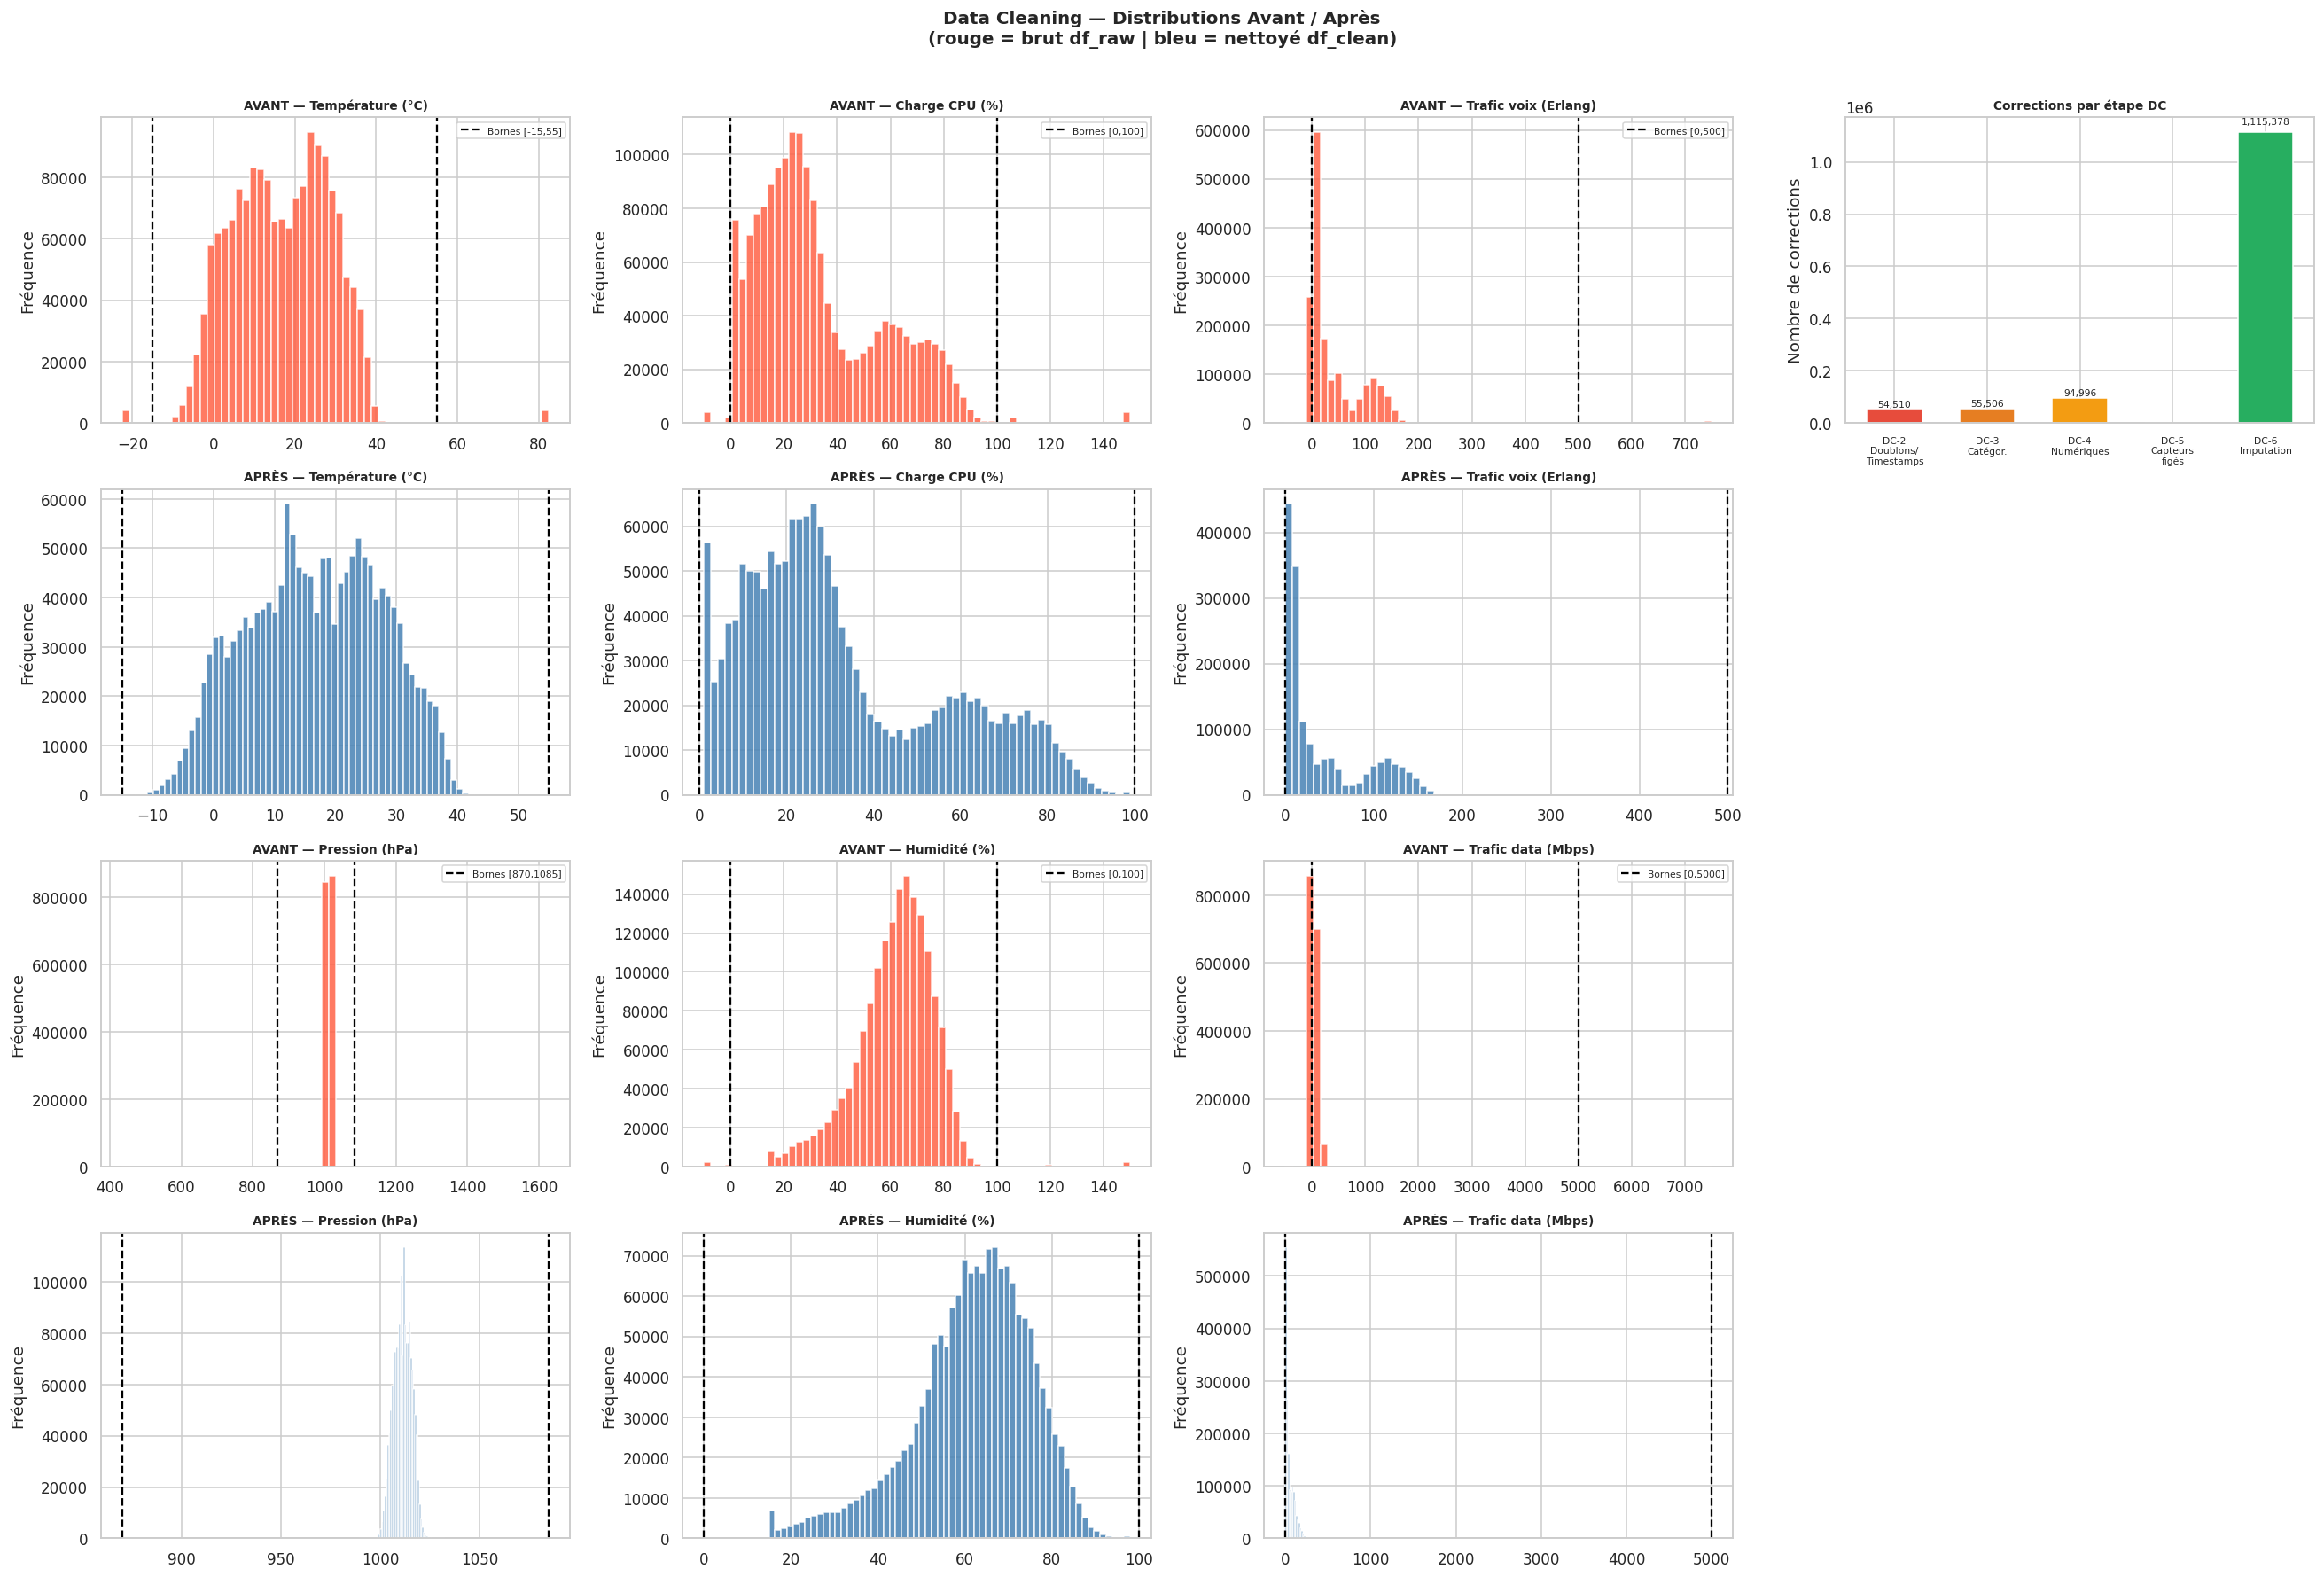

  Figure sauvegardée : outputs/data_cleaning_avant_apres.png

  df_raw mis à jour ← df_clean  (1,577,021 lignes × 29 colonnes)
Données nettoyées prêtes — passage au Feature Engineering (Phase 2)


In [13]:
# CELLULE DC-7 — BILAN & VISUALISATION AVANT / APRÈS

print('  BILAN DATA CLEANING — DC-2 → DC-6')

print(f'  Lignes initiales (df_raw)   : {len(df_raw):>12,}')
print(f'  Lignes après nettoyage      : {len(df_clean):>12,}')
n_supp = len(df_raw) - len(df_clean)
print(f'  Lignes supprimées           : {n_supp:>12,}  ({n_supp/len(df_raw)*100:.1f}%)')
print()
print('  DC-2 | Doublons & timestamps invalides  → supprimés')
print('  DC-3 | Catégorielles hors référentiel   → NaN, puis supprimés si clé')
print('  DC-4 | Numériques hors bornes physiques → NaN  (bornes canoniques ETSI/ITU)')
print('  DC-5 | Capteurs figés (run ≥ 20)        → NaN')
print('  DC-6 | Tous NaN résiduels               → imputés (médiane contextuelle, anti-leakage)')
print()

#  Vérification finale ─
COLS_CRITIQUES = [
    'timestamp','station_id','gouvernorat','technologie','type_zone',
    'consommation_kwh','charge_cpu_pct','trafic_voix_erlang','trafic_data_mbps',
    'temperature_ambiante','heure','mois','annee',
]
nan_fin = df_clean[COLS_CRITIQUES].isnull().sum()
nan_fin = nan_fin[nan_fin > 0]
if nan_fin.empty:
    print(' Aucun NaN dans les colonnes critiques — dataset prêt.')
else:
    print(' NaN résiduels dans colonnes critiques :')
    print(nan_fin.to_string())
print()

#  Visualisation avant / après ─
COLS_VIZ = [
    ('temperature_ambiante',         -15,   55,  'Température (°C)'),
    ('charge_cpu_pct',                  0,  100,  'Charge CPU (%)'),
    ('trafic_voix_erlang',              0,  500,  'Trafic voix (Erlang)'),
    ('pression_atmospherique_hpa',    870, 1085,  'Pression (hPa)'),
    ('humidite_relative_pct',           0,  100,  'Humidité (%)'),
    ('trafic_data_mbps',                0, 5000,  'Trafic data (Mbps)'),
]

# Grille 3×4 :
#   Ligne 0 (axes[0,0..2]) : AVANT  colonnes 0-1-2
#   Ligne 1 (axes[1,0..2]) : APRÈS  colonnes 0-1-2
#   Ligne 2 (axes[2,0..2]) : AVANT  colonnes 3-4-5
#   Ligne 3 (axes[3,0..2]) : APRÈS  colonnes 3-4-5
fig, axes = plt.subplots(4, 4, figsize=(24, 16))
fig.suptitle(
    'Data Cleaning — Distributions Avant / Après\n'
    '(rouge = brut df_raw | bleu = nettoyé df_clean)',
    fontsize=13, fontweight='bold', y=1.01
)

for j, (col, lo, hi, label) in enumerate(COLS_VIZ):
    bloc   = j // 3          # 0 pour cols 0-2, 1 pour cols 3-5
    pos    = j % 3           # position dans le bloc (0,1,2)
    row_a  = bloc * 2        # ligne AVANT : 0 ou 2
    row_b  = bloc * 2 + 1   # ligne APRÈS : 1 ou 3

    clip_lo_v = lo - abs(lo) * 0.5 if lo != 0 else -hi * 0.1
    clip_hi_v = hi + abs(hi) * 0.5

    avant_data = pd.to_numeric(df_raw[col], errors='coerce').dropna().clip(clip_lo_v, clip_hi_v)
    apres_data = df_clean[col].dropna().clip(lo, hi)

    # AVANT
    axes[row_a, pos].hist(avant_data, bins=60, color='tomato', alpha=0.85, edgecolor='white')
    axes[row_a, pos].axvline(lo, color='black', lw=1.5, ls='--')
    axes[row_a, pos].axvline(hi, color='black', lw=1.5, ls='--', label=f'Bornes [{lo},{hi}]')
    axes[row_a, pos].set_title(f'AVANT — {label}', fontweight='bold', fontsize=9)
    axes[row_a, pos].set_ylabel('Fréquence')
    axes[row_a, pos].legend(fontsize=7)

    # APRÈS
    axes[row_b, pos].hist(apres_data, bins=60, color='steelblue', alpha=0.85, edgecolor='white')
    axes[row_b, pos].axvline(lo, color='black', lw=1.5, ls='--')
    axes[row_b, pos].axvline(hi, color='black', lw=1.5, ls='--')
    axes[row_b, pos].set_title(f'APRÈS — {label}', fontweight='bold', fontsize=9)
    axes[row_b, pos].set_ylabel('Fréquence')

# Supprimer les cases vides de la colonne 3 (sauf axes[0,3] pour le bar chart)
for row in [0, 1, 2, 3]:
    if row != 0:
        fig.delaxes(axes[row, 3])

# Bar chart récapitulatif dans axes[0,3]
etapes = ['DC-2\nDoublons/\nTimestamps', 'DC-3\nCatégor.', 'DC-4\nNumériques',
          'DC-5\nCapteurs\nfigés', 'DC-6\nImputation']
recap_vals = [
    n_dup + n_nat + n_hp,
    n_gov_bad + n_tech_bad + n_zone_bad + n_st_bad,
    total_conv + total_hors,
    total_figes,
    total_imputes,
]
colors_recap = ['#e74c3c','#e67e22','#f39c12','#9b59b6','#27ae60']
bars = axes[0, 3].bar(etapes, recap_vals, color=colors_recap, edgecolor='white', width=0.6)
axes[0, 3].set_title('Corrections par étape DC', fontweight='bold', fontsize=9)
axes[0, 3].set_ylabel('Nombre de corrections')
axes[0, 3].tick_params(axis='x', labelsize=7)
for bar, val in zip(bars, recap_vals):
    if val > 0:
        axes[0, 3].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                        f'{val:,}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('outputs/data_cleaning_avant_apres.png', dpi=110, bbox_inches='tight')
plt.show()
print('  Figure sauvegardée : outputs/data_cleaning_avant_apres.png')

#  Commit df_raw ← df_clean ─
df_raw = df_clean.copy()
print(f'\n  df_raw mis à jour ← df_clean  ({len(df_raw):,} lignes × {len(df_raw.columns)} colonnes)')
print('Données nettoyées prêtes — passage au Feature Engineering (Phase 2)')


---
## Phase 2 — Préparation des Données

> **Principe anti-data-leakage :** toutes les statistiques de référence
> (médianes, encodeurs, percentiles) sont calculées **uniquement sur le train (2022-2023)**,
> puis appliquées au jeu de test (2024).


In [14]:
# Cellule 2 — Fonctions de prétraitement
#
# Après le Data Cleaning (DC-2 → DC-6), df_raw est déjà :
#   • Sans doublons ni timestamps invalides
#   • Avec colonnes temporelles cohérentes
#   • Avec valeurs hors bornes physiques → NaN imputées
#   • Sans capteurs figés
# → nettoyer() effectue uniquement une vérification légère de la cible
#   et des colonnes obligatoires, sans refiltrage des bornes.
# → imputer() est conservée pour la robustesse mais ne trouvera généralement
#   aucun NaN résiduel après DC-6.


def nettoyer(df: pd.DataFrame) -> pd.DataFrame:
    """Vérifie la cohérence minimale après Data Cleaning.

    Après DC-2 → DC-6, les bornes physiques ont déjà été appliquées (DC-4)
    et les NaN imputés (DC-6). Cette fonction se limite à :
      • Supprimer les lignes avec consommation_kwh ≤ 0 (sécurité)
      • Supprimer les lignes avec NaN dans les colonnes obligatoires du pipeline
    Elle ne redéfinit PAS de nouvelles bornes pour éviter toute incohérence
    avec les bornes canoniques de DC-4.
    """
    COLS_OBLIGATOIRES = [
        'consommation_kwh', 'heure', 'mois', 'annee',
        'technologie', 'type_zone', 'gouvernorat',
    ]
    masque = (df['consommation_kwh'] > 0) & df[COLS_OBLIGATOIRES].notna().all(axis=1)
    n_sup = (~masque).sum()
    if n_sup > 0:
        print(f'  [nettoyer] {n_sup:,} lignes supprimées (cible ≤ 0 ou colonne obligatoire NaN)')
    return df[masque].copy()


def imputer(df: pd.DataFrame, df_train_ref: pd.DataFrame) -> pd.DataFrame:
    """Impute les NaN résiduels éventuels par médiane contextuelle (train).

    Après DC-6, cette fonction ne devrait trouver aucun NaN résiduel.
    Elle est conservée comme filet de sécurité pour le pipeline.
    """
    COLS = [
        'trafic_voix_erlang', 'trafic_data_mbps', 'nb_utilisateurs_actifs',
        'charge_cpu_pct', 'temperature_ambiante',
        'humidite_relative_pct', 'vitesse_vent_ms', 'rayonnement_solaire_wm2',
        'precipitation_mmh', 'pression_atmospherique_hpa', 'indice_uv',
    ]
    imputed_any = False
    for col in COLS:
        if col not in df.columns:
            continue
        n_nan = df[col].isnull().sum()
        if n_nan == 0:
            continue
        imputed_any = True
        med_ctx  = df_train_ref.groupby(['heure', 'type_zone'])[col].median()
        med_glob = df_train_ref[col].median()
        idx_nan  = df.index[df[col].isnull()]
        keys     = list(zip(df.loc[idx_nan, 'heure'], df.loc[idx_nan, 'type_zone']))
        vals     = [med_ctx.get(k, med_glob) for k in keys]
        df.loc[idx_nan, col] = vals
        print(f'  [imputer] {col:30s} : {n_nan:,} NaN imputés')
    if not imputed_any:
        print('  [imputer] Aucun NaN résiduel détecté — données déjà propres (DC-6).')
    return df


def encoder_categoriel(df_train, df_test):
    le_tech = LabelEncoder().fit(df_train['technologie'])
    le_zone = LabelEncoder().fit(df_train['type_zone'])
    le_gov  = LabelEncoder().fit(df_train['gouvernorat'])

    def safe_enc(le, col):
        known  = set(le.classes_)
        mapped = col.map(lambda x: x if x in known else le.classes_[0])
        return le.transform(mapped)

    for subset in [df_train, df_test]:
        subset['technologie_enc'] = safe_enc(le_tech, subset['technologie'])
        subset['type_zone_enc']   = safe_enc(le_zone, subset['type_zone'])
        subset['gouvernorat_enc'] = safe_enc(le_gov,  subset['gouvernorat'])
    return df_train, df_test, le_tech, le_zone, le_gov

def encoder_station(df_train, df_test, target='consommation_kwh', alpha=10):
    global_mean = df_train[target].mean()
    stats = df_train.groupby('station_id')[target].agg(['mean', 'count'])
    stats['enc'] = (
        (stats['mean'] * stats['count'] + global_mean * alpha)
        / (stats['count'] + alpha)
    )
    fallback = df_train.groupby(['technologie', 'type_zone'])[target].mean()
    
    def encode_row(row, enc_map, fallback_map):
        if row['station_id'] in enc_map:
            return enc_map[row['station_id']]
        key = (row['technologie'], row['type_zone'])
        return fallback_map.get(key, global_mean)
    
    df_train['station_enc'] = df_train['station_id'].map(stats['enc']).fillna(global_mean)
    df_test['station_enc'] = df_test.apply(
        lambda r: encode_row(r, stats['enc'], fallback), axis=1
    )
    return df_train, df_test, stats['enc']
    
print('Fonctions de prétraitement définies')
print('  nettoyer() : vérification légère (cohérence cible + colonnes obligatoires)')
print('  imputer()  : filet de sécurité (NaN résiduels post DC-6)')
print('  encoder_categoriel() : LabelEncoder fit sur train uniquement')

Fonctions de prétraitement définies
  nettoyer() : vérification légère (cohérence cible + colonnes obligatoires)
  imputer()  : filet de sécurité (NaN résiduels post DC-6)
  encoder_categoriel() : LabelEncoder fit sur train uniquement


In [15]:
# Cellule 3 — Fonctions de feature engineering

MAX_WINDOW = 24 * 7  # 168 h — fenêtre glissante maximale

def ajouter_ratios_efficacite(df):
    df['charge_par_secteur']   = df['charge_cpu_pct'] / df['nb_secteurs_actifs']
    df['efficacite_spectrale'] = (
        (df['trafic_data_mbps'] + 1)
        / (df['puissance_emission_dbm'] - 30 + 1).clip(lower=1)  
    )
    df['intensite_trafic']     = df['nb_utilisateurs_actifs'] / (df['trafic_data_mbps'] + 0.1)
    df['charge_thermique']     = np.maximum(0, df['temperature_ambiante'] - 28)
    df['trafic_x_temp'] = (
        df['trafic_data_mbps'] * np.maximum(0, df['temperature_ambiante'] - 20) / 100
    )
    df['charge_cpu_x_secteurs'] = df['charge_cpu_pct'] * df['nb_secteurs_actifs']
    return df


def ajouter_features_meteo(df: pd.DataFrame) -> pd.DataFrame:
    """Construit les features dérivées des colonnes météo.
    Sources : ETSI EN 300 019-1-4, ITU-T L.1311, ITU-R P.838, NOAA Heat Index.
    """
    T = df['temperature_ambiante']
    H = df['humidite_relative_pct']

    heat_index = (
        -8.78469475556
        + 1.61139411    * T
        + 2.33854883889 * H
        - 0.14611605    * T * H
        - 0.012308094   * T**2
        - 0.0164248277778 * H**2
        + 0.002211732   * T**2 * H
        + 0.00072546    * T * H**2
        - 0.000003582   * T**2 * H**2
    )
    df['heat_index'] = heat_index.where((T > 26) & (H > 40), other=T)
    df['est_pluie'] = (df['precipitation_mmh'] > 0.1).astype(int)
    df['categorie_pluie'] = pd.cut(
        df['precipitation_mmh'],
        bins=[-0.001, 0.1, 2.5, 7.5, 50.0, 9999.0],
        labels=[0, 1, 2, 3, 4]
    ).astype(int)
    df['charge_thermique_solaire'] = (
        df['rayonnement_solaire_wm2'] * (1 - 0.003 * df['humidite_relative_pct'])
    ).clip(lower=0)
    df['efficacite_free_cooling'] = (
        (1 / (1 + np.exp(0.3 * (T - 20))))
        * (1 - np.exp(-df['vitesse_vent_ms'] / 5))
        * (1 - 0.004 * (H - 50).clip(lower=0))
    ).clip(0, 1)
    return df


def ajouter_rolling_train(df_train: pd.DataFrame) -> pd.DataFrame:
    """Calcule les moyennes glissantes sur le jeu d'entraînement."""
    df_train = df_train.copy()
    df_train['conso_moy_24h'] = (
        df_train.groupby('station_id')['consommation_kwh']
                .transform(lambda x: x.rolling(24, min_periods=1).mean().shift(1))
    )
    df_train['conso_moy_48h'] = (
        df_train.groupby('station_id')['consommation_kwh']
                .transform(lambda x: x.rolling(48, min_periods=1).mean().shift(1))
    )
    df_train['conso_moy_7j'] = (
        df_train.groupby('station_id')['consommation_kwh']
                .transform(lambda x: x.rolling(168, min_periods=1).mean().shift(1))
    )
    return df_train


def ajouter_rolling_test(df_train: pd.DataFrame, df_test: pd.DataFrame) -> pd.DataFrame:
    """Calcule les moyennes glissantes sur le test en utilisant la queue du train comme contexte."""
    queue = (
        df_train.groupby('station_id', group_keys=False)
                .apply(lambda g: g.sort_values('timestamp').tail(MAX_WINDOW))
    ).copy()
    queue['_ctx'] = True
    df_test = df_test.copy()
    df_test['_ctx'] = False
    combined = pd.concat([queue, df_test]).sort_values(
        ['station_id', 'timestamp']
    ).reset_index(drop=True)
    for win, col in [(24, 'conso_moy_24h'), (48, 'conso_moy_48h'), (24*7, 'conso_moy_7j')]:
        combined[col] = (
            combined.groupby('station_id')['consommation_kwh']
                    .transform(lambda x: x.rolling(win, min_periods=1).mean().shift(1))
        )
    return combined[combined['_ctx'] == False].drop(columns=['_ctx'])


def ajouter_lags_et_tendance(df_train, df_test):
    MAX_LAG = 6
    LAGS_PERIODIQUES = [24, 48, 168]
    MAX_CONTEXT = max(LAGS_PERIODIQUES) + 10

    queue = (
        df_train.groupby('station_id', group_keys=False)
                .apply(lambda g: g.sort_values('timestamp').tail(MAX_CONTEXT))
    ).copy()
    queue['_ctx'] = True
    df_test = df_test.copy()
    df_test['_ctx'] = False
    combined = pd.concat([queue, df_test]).sort_values(
        ['station_id', 'timestamp']).reset_index(drop=True)

    for lag in range(1, MAX_LAG + 1):
        combined[f'conso_lag_{lag}h'] = (
            combined.groupby('station_id')['consommation_kwh']
                    .transform(lambda x: x.shift(lag)))
        combined[f'cpu_lag_{lag}h'] = (
            combined.groupby('station_id')['charge_cpu_pct']
                    .transform(lambda x: x.shift(lag)))
    for lag in LAGS_PERIODIQUES:
        combined[f'conso_lag_{lag}h'] = (
            combined.groupby('station_id')['consommation_kwh']
                    .transform(lambda x: x.shift(lag)))

    # Calculer tendance_3h sur combined (avec contexte queue) AVANT de filtrer
    combined['tendance_3h'] = (
        combined.groupby('station_id')['consommation_kwh']
         .transform(lambda x:
             x.rolling(3, min_periods=2).mean().shift(1)
             - x.rolling(6, min_periods=3).mean().shift(1)))
    
    df_test = combined[combined['_ctx'] == False].drop(columns=['_ctx'])
    
    # tendance_3h pour df_train (pas de contexte disponible → comportement inchangé)
    df_train['tendance_3h'] = (
        df_train.groupby('station_id')['consommation_kwh']
         .transform(lambda x:
             x.rolling(3, min_periods=2).mean().shift(1)
             - x.rolling(6, min_periods=3).mean().shift(1)))

    for lag in range(1, MAX_LAG + 1):
        df_train[f'conso_lag_{lag}h'] = (
            df_train.groupby('station_id')['consommation_kwh']
                    .transform(lambda x: x.shift(lag)))
        df_train[f'cpu_lag_{lag}h'] = (
            df_train.groupby('station_id')['charge_cpu_pct']
                    .transform(lambda x: x.shift(lag)))
    for lag in LAGS_PERIODIQUES:
        df_train[f'conso_lag_{lag}h'] = (
            df_train.groupby('station_id')['consommation_kwh']
                    .transform(lambda x: x.shift(lag)))
    
    
    return df_train, df_test


def ajouter_eei(df: pd.DataFrame, df_train_ref: pd.DataFrame) -> pd.DataFrame:
    """Calcule l'Energy Efficiency Index (EEI) — référence calculée sur le train."""
    df = df.drop(columns=['conso_reference_groupe'], errors='ignore')
    ref = (
        df_train_ref
        .groupby(['technologie', 'type_zone', 'heure'])['consommation_kwh']
        .median()
        .reset_index()
        .rename(columns={'consommation_kwh': 'conso_reference_groupe'})
    )
    med_glob = df_train_ref['consommation_kwh'].median()
    df = df.merge(ref, on=['technologie', 'type_zone', 'heure'], how='left')
    df['conso_reference_groupe'] = df['conso_reference_groupe'].fillna(med_glob)
    df['eei'] = (df['consommation_kwh'] / df['conso_reference_groupe'].clip(lower=0.01)) * 100
    df['eei_categorie'] = pd.cut(
        df['eei'],
        bins=[0, 70, 90, 110, 130, float('inf')],
        labels=['Sous-utilisée', 'Efficace', 'Normale', 'Dégradée', 'Critique']
    )
    return df


def ajouter_ecart_profil(df: pd.DataFrame, df_train_ref: pd.DataFrame) -> pd.DataFrame:
    """Ajoute l'écart vs profil horaire de référence (train uniquement)."""
    ref = (
        df_train_ref
        .groupby(['heure', 'type_zone', 'technologie'])['consommation_kwh']
        .median()
        .reset_index()
        .rename(columns={'consommation_kwh': 'mediane_ref_profil'})
    )
    med_glob = df_train_ref['consommation_kwh'].median()
    df = df.merge(ref, on=['heure', 'type_zone', 'technologie'], how='left')
    df['mediane_ref_profil'] = df['mediane_ref_profil'].fillna(med_glob)
    df['ecart_vs_profil_horaire'] = (
        (df['consommation_kwh'] - df['mediane_ref_profil'])
        / df['mediane_ref_profil'].clip(lower=0.1)
    )
    return df


def ajouter_anomalie_ref(df: pd.DataFrame, df_train_ref: pd.DataFrame) -> pd.DataFrame:
    """Calcule une référence d'anomalie préliminaire et la durée d'anomalie."""
    ref_anom = (
        df_train_ref
        .groupby(['heure', 'type_zone', 'technologie'])['consommation_kwh']
        .median()
        .reset_index()
        .rename(columns={'consommation_kwh': 'mediane_anom_ref'})
    )
    med_glob = df_train_ref['consommation_kwh'].median()
    df = df.merge(ref_anom, on=['heure', 'type_zone', 'technologie'], how='left')
    df['mediane_anom_ref'] = df['mediane_anom_ref'].fillna(med_glob)

    df['en_anomalie_prel'] = (
        (df.groupby('station_id')['consommation_kwh'].shift(1)
         .fillna(df['mediane_anom_ref'])         # ← référence neutre, pas cible
         - df['mediane_anom_ref'])               # ← opération rétablie
        / df['mediane_anom_ref'].clip(lower=0.1) > 0.30
    ).astype(int)

    df['duree_anomalie'] = (
        df.groupby('station_id')['en_anomalie_prel']
          .transform(lambda x: x.groupby((x != x.shift()).cumsum()).cumcount())
    )
    return df

def ajouter_features_temporelles_cycliques(df: pd.DataFrame) -> pd.DataFrame:
    """Encode heure, jour, mois en sin/cos (espace continu, 23h ↔ 0h).
    Ajoute aussi mois_annee pour capturer le drift long-terme (2022→2024).
    """
    df['heure_sin']  = np.sin(2 * np.pi * df['heure'] / 24)
    df['heure_cos']  = np.cos(2 * np.pi * df['heure'] / 24)
    df['jour_sin']   = np.sin(2 * np.pi * df['jour_semaine'] / 7)
    df['jour_cos']   = np.cos(2 * np.pi * df['jour_semaine'] / 7)
    df['mois_sin']   = np.sin(2 * np.pi * df['mois'] / 12)
    df['mois_cos']   = np.cos(2 * np.pi * df['mois'] / 12)
    df['mois_annee'] = (df['annee'] - 2022) * 12 + df['mois']  # drift annuel
    return df

print('Fonctions de feature engineering définies')

Fonctions de feature engineering définies


In [16]:
# Cellule 4 — Pipeline de préparation complet

print(' PIPELINE DE PRÉPARATION DES DONNÉES ')
t0 = time.time()

# 1. Nettoyage
print('\n[1/7] Nettoyage physique...')
df = nettoyer(df_raw.copy())

# 2. Split précoce train/test (avant toute imputation)
df_train_raw = df[df['annee'] < 2024].copy()
df_test_raw  = df[df['annee'] == 2024].copy()

# 3. Imputation (médianes calculées sur train uniquement)
print('[2/7] Imputation des valeurs manquantes...')
df_train_raw = imputer(df_train_raw, df_train_raw)
df_test_raw  = imputer(df_test_raw, df_train_raw)

# 4. Encodage catégoriel (fit sur train uniquement)
print('[3/7] Encodage catégoriel...')
df_train_raw, df_test_raw, le_tech, le_zone, le_gov = encoder_categoriel(df_train_raw, df_test_raw)
df_train_raw, df_test_raw, station_enc_map = encoder_station(df_train_raw, df_test_raw)

# 5. Features temporelles cycliques, ratios et features météo dérivées
# Aucun risque de data leakage : ces features ne dépendent que des colonnes
# brutes de la ligne courante (pas de statistiques calculées sur d'autres lignes).
print('[4/7] Features cycliques, ratios & météo...')
for d_name in ['train', 'test']:
    d = df_train_raw if d_name == 'train' else df_test_raw
    d = ajouter_features_temporelles_cycliques(d)
    d = ajouter_ratios_efficacite(d)
    d = ajouter_features_meteo(d)
    if d_name == 'train':
        df_train_raw = d
    else:
        df_test_raw = d

df_train_raw = df_train_raw.sort_values(['station_id','timestamp']).reset_index(drop=True)
df_test_raw = df_test_raw.sort_values(['station_id','timestamp']).reset_index(drop=True)

# 6. Rolling windows (contexte train → test)
print('[5/7] Moyennes glissantes (rolling)...')
df_train_raw = ajouter_rolling_train(df_train_raw)
df_test_raw  = ajouter_rolling_test(df_train_raw, df_test_raw)

# 7. Lags & tendances
print('[6/7] Lags temporels & tendances...')
df_train_raw, df_test_raw = ajouter_lags_et_tendance(df_train_raw, df_test_raw)

# Consommation moyenne par station (référence train uniquement)
# Feature station-niveau : capture la baseline de consommation propre à chaque BTS
# (puissance installée, technologie, environnement local).
# Calculée sur df_train_raw uniquement → aucun leakage.
station_mean = (
    df_train_raw.groupby('station_id')['consommation_kwh']
                .mean()
                .rename('conso_moy_station')
)
df_train_raw = df_train_raw.merge(station_mean, on='station_id', how='left')
df_test_raw  = df_test_raw.merge(station_mean,  on='station_id', how='left')
# Stations absentes du train → médiane globale du train
glob_med = df_train_raw['conso_moy_station'].median()
df_train_raw['conso_moy_station'] = df_train_raw['conso_moy_station'].fillna(glob_med)
df_test_raw['conso_moy_station']  = df_test_raw['conso_moy_station'].fillna(glob_med)

# 8. EEI, écart profil, anomalie ref (toutes basées sur train)
print('[7/7] EEI, écart profil, anomalie référence...')
df = pd.concat([df_train_raw, df_test_raw]).sort_values(
    ['station_id', 'timestamp']
).reset_index(drop=True)

df = ajouter_eei(df, df[df['annee'] < 2024])
df = ajouter_ecart_profil(df, df[df['annee'] < 2024])
df = ajouter_anomalie_ref(df, df[df['annee'] < 2024])

# Remplissage NaN résiduels (lags des premières lignes)
lag_cols = (
    [f'conso_lag_{i}h' for i in range(1, 7)] +
    [f'cpu_lag_{i}h'   for i in range(1, 7)] +
    ['conso_lag_24h', 'conso_lag_48h', 'conso_lag_168h',  
     'tendance_3h', 'duree_anomalie']
)
for col in lag_cols:
    df[col] = df.groupby('station_id')[col].transform(
        lambda x: x.fillna(x.median())
    )
    df[col] = df[col].fillna(df[col].median())

# est_ramadan : calendrier islamique officiel Tunisie 2022-2024
RAMADAN = [
    ('2022-04-02', '2022-05-01'),
    ('2023-03-23', '2023-04-21'),
    ('2024-03-11', '2024-04-09'),
]
ramadan_mask = pd.Series(False, index=df.index)
for start, end in RAMADAN:
    ramadan_mask |= df['timestamp'].between(pd.Timestamp(start), pd.Timestamp(end))
df['est_ramadan'] = ramadan_mask.astype(int)

# est_ferie : jours fériés tunisiens 2022-2024 (fixes + islamiques)
FERIES = [
    # Fériés nationaux fixes
    '2022-01-01','2022-03-20','2022-04-09','2022-05-01',
    '2022-07-25','2022-08-13','2022-10-15',
    '2023-01-01','2023-03-20','2023-04-09','2023-05-01',
    '2023-07-25','2023-08-13','2023-10-15',
    '2024-01-01','2024-03-20','2024-04-09','2024-05-01',
    '2024-07-25','2024-08-13','2024-10-15',
    # Eid Al-Fitr
    '2022-05-02','2022-05-03',
    '2023-04-21','2023-04-22',
    '2024-04-10','2024-04-11',
    # Eid Al-Adha
    '2022-07-09','2022-07-10',
    '2023-06-28','2023-06-29',
    '2024-06-16','2024-06-17',
    # Ras El Am Hijri + Mawlid
    '2022-07-30','2022-10-08',
    '2023-07-19','2023-09-27',
    '2024-07-07','2024-09-15',
]
feries_set = set(pd.to_datetime(FERIES).normalize())
df['est_ferie'] = df['timestamp'].dt.normalize().isin(feries_set).astype(int)

print(f"  est_ramadan : {df['est_ramadan'].sum():,} heures ({df['est_ramadan'].mean()*100:.1f}%)")
print(f"  est_ferie   : {df['est_ferie'].sum():,} heures ({df['est_ferie'].mean()*100:.1f}%)")


 PIPELINE DE PRÉPARATION DES DONNÉES 

[1/7] Nettoyage physique...
[2/7] Imputation des valeurs manquantes...
  [imputer] Aucun NaN résiduel détecté — données déjà propres (DC-6).
  [imputer] Aucun NaN résiduel détecté — données déjà propres (DC-6).
[3/7] Encodage catégoriel...
[4/7] Features cycliques, ratios & météo...
[5/7] Moyennes glissantes (rolling)...
[6/7] Lags temporels & tendances...
[7/7] EEI, écart profil, anomalie référence...
  est_ramadan : 125,508 heures (8.0%)
  est_ferie   : 56,139 heures (3.6%)


In [17]:
# Cellule 4b — Calcul des indicateurs QoS

# Ces indicateurs sont construits a partir des colonnes disponibles dans le dataset.
# Ils remplissent trois roles dans le projet :
#   1. Features predictives pour le modele de consommation (NB1)
#   2. Critere de qualification des clusters et des anomalies (NB2)
#   3. Garde-fou dans le moteur de regles d'optimisation (NB3)

# Les indicateurs sont calcules sur df complet (train + test) car ils ne dependent
# que des colonnes brutes de la ligne courante — aucun risque de data leakage.

# Capacites nominales par technologie 
# Valeurs issues des specifications 3GPP et des recommandations ITU-R M.2012.
# Erlang = trafic voix absorbe sans blocage par secteur.
# Mbps   = debit data maximal par secteur dans des conditions normales.
CAPACITE_VOIX_PAR_SECTEUR  = {'2G': 30,  '3G': 80,  '4G': 150, '4G+': 200}  # Erlang
CAPACITE_DATA_PAR_SECTEUR  = {'2G': 0.5, '3G': 20,  '4G': 100, '4G+': 200}  # Mbps

cap_voix_serie = df['technologie'].map(CAPACITE_VOIX_PAR_SECTEUR).fillna(100)
cap_data_serie = df['technologie'].map(CAPACITE_DATA_PAR_SECTEUR).fillna(50)

df['capacite_voix_erlang'] = cap_voix_serie * df['nb_secteurs_actifs']
df['capacite_data_mbps']   = cap_data_serie * df['nb_secteurs_actifs']

# Indicateur 1 : Taux de charge voix [0, 1]
# Mesure la saturation de la capacite voix.
# Interpretation : au-dessus de 0.80 le taux de blocage Erlang-B depasse 2%,
# seuil typique des SLA operateurs (ITU-T E.501).
df['taux_charge_voix'] = (
    df['trafic_voix_erlang'] / df['capacite_voix_erlang'].clip(lower=1)
).clip(0, 1)

# Indicateur 2 : Taux de charge data [0, 1] 
# Mesure le remplissage de la capacite data par secteur.
# Au-dessus de 0.80 la latence augmente significativement (3GPP TS 22.261).
df['taux_charge_data'] = (
    df['trafic_data_mbps'] / df['capacite_data_mbps'].clip(lower=0.1)
).clip(0, 1)

# Indicateur 3 : Stress radio [0, 1]
# Combine la puissance d'emission, la charge CPU et la charge voix.
# Une puissance elevee avec CPU sature indique une degradation de la couverture
# ou un probleme de site (antenne, connectique).
# Normalisation puissance sur la plage observee [30.7, 47.6] dBm.
df_train_ref_qos = df[df['annee'] < 2024]
PMIN_DBM = float(df_train_ref_qos['puissance_emission_dbm'].quantile(0.01))  # P1 empirique
PMAX_DBM = float(df_train_ref_qos['puissance_emission_dbm'].quantile(0.99))  # P99 empirique
# Garde-fou : si la plage est trop étroite, fallback sur les bornes physiques
if (PMAX_DBM - PMIN_DBM) < 5:
    PMIN_DBM, PMAX_DBM = 20.0, 60.0
print(f'  Plage normalisation stress_radio : [{PMIN_DBM:.1f}, {PMAX_DBM:.1f}] dBm (P1-P99 train)')
df['stress_radio'] = (
    ((df['puissance_emission_dbm'] - PMIN_DBM) / (PMAX_DBM - PMIN_DBM)) * 0.50
    + (df['charge_cpu_pct'] / 100)                                        * 0.30
    + df['taux_charge_voix']                                               * 0.20
).clip(0, 1)

# score_qualite_radio : 1 = aucun stress, 0 = station completement saturee
df['score_qualite_radio'] = (1 - df['stress_radio']).round(4)

# Indicateur 4 : Score QoS global [0, 1]
# Agregation ponderee des trois dimensions.
# Poids : data 50% (priorite usage dominant 4G/4G+), voix 30%, radio 20%.
# Ce score est l'indicateur de reference utilise dans NB2 (clustering)
# et NB3 (garde-fou des regles d'optimisation).
df['score_qos'] = (
    (1 - df['taux_charge_data'])  * 0.50
    + (1 - df['taux_charge_voix']) * 0.30
    + df['score_qualite_radio']    * 0.20
).clip(0, 1).round(4)

# Indicateur 5 : Classe QoS ordinale 
# Discretisation du score_qos en 4 classes utilisables comme etiquette
# dans les modeles de classification et les systemes de regles (NB3).
#   Critique   : score < 0.40 — action immediate requise
#   Degradee   : 0.40 <= score < 0.60 — surveillance renforcee
#   Acceptable : 0.60 <= score < 0.80 — fonctionnement normal sous charge
#   Bonne      : score >= 0.80 — marge disponible pour optimisation energetique
df['classe_qos'] = pd.cut(
    df['score_qos'],
    bins   = [0.0, 0.40, 0.60, 0.80, 1.001],
    labels = ['Critique', 'Degradee', 'Acceptable', 'Bonne']
)

# Indicateur 6 : Garde-fou optimisation 
# Colonne binaire precalculee : 1 si une action d'optimisation energetique
# (reduction puissance, sleep mode secteur) peut etre proposee sans risquer
# de degrader la QoS sous le seuil minimum acceptable.
# Seuil de 0.60 = classe Acceptable — valeur reglable selon la politique operateur.
QOS_SEUIL_OPTIMISATION = 0.60
df['optimisation_qos_autorisee'] = (
    (df['score_qos']        >= QOS_SEUIL_OPTIMISATION) &
    (df['taux_charge_data'] <= 0.80) &
    (df['taux_charge_voix'] <= 0.80)
).astype(int)

# Verification et bilan
print('Indicateurs QoS calcules.')
print(f'  Colonnes ajoutees : capacite_voix_erlang, capacite_data_mbps,')
print(f'                      taux_charge_voix, taux_charge_data,')
print(f'                      stress_radio, score_qualite_radio,')
print(f'                      score_qos, classe_qos, optimisation_qos_autorisee')
print()
print('Repartition des classes QoS :')
repartition = df['classe_qos'].value_counts().sort_index()
for classe, n in repartition.items():
    pct = n / len(df) * 100
    print(f'  {str(classe):12s} : {n:>9,} lignes ({pct:5.1f}%)')
print()
print(f'Stations ou optimisation autorisee : '
      f"{df['optimisation_qos_autorisee'].mean()*100:.1f}% des observations")
print(f'Score QoS moyen global             : {df["score_qos"].mean():.3f}')
print(f'Score QoS moyen par technologie :')
print(df.groupby('technologie')['score_qos'].mean().round(3).to_string())


  Plage normalisation stress_radio : [32.6, 47.2] dBm (P1-P99 train)
Indicateurs QoS calcules.
  Colonnes ajoutees : capacite_voix_erlang, capacite_data_mbps,
                      taux_charge_voix, taux_charge_data,
                      stress_radio, score_qualite_radio,
                      score_qos, classe_qos, optimisation_qos_autorisee

Repartition des classes QoS :
  Critique     :    94,272 lignes (  6.0%)
  Degradee     :   175,081 lignes ( 11.1%)
  Acceptable   :   385,481 lignes ( 24.4%)
  Bonne        :   922,185 lignes ( 58.5%)

Stations ou optimisation autorisee : 82.8% des observations
Score QoS moyen global             : 0.761
Score QoS moyen par technologie :
technologie
2G     0.576
3G     0.754
4G     0.770
4G+    0.790


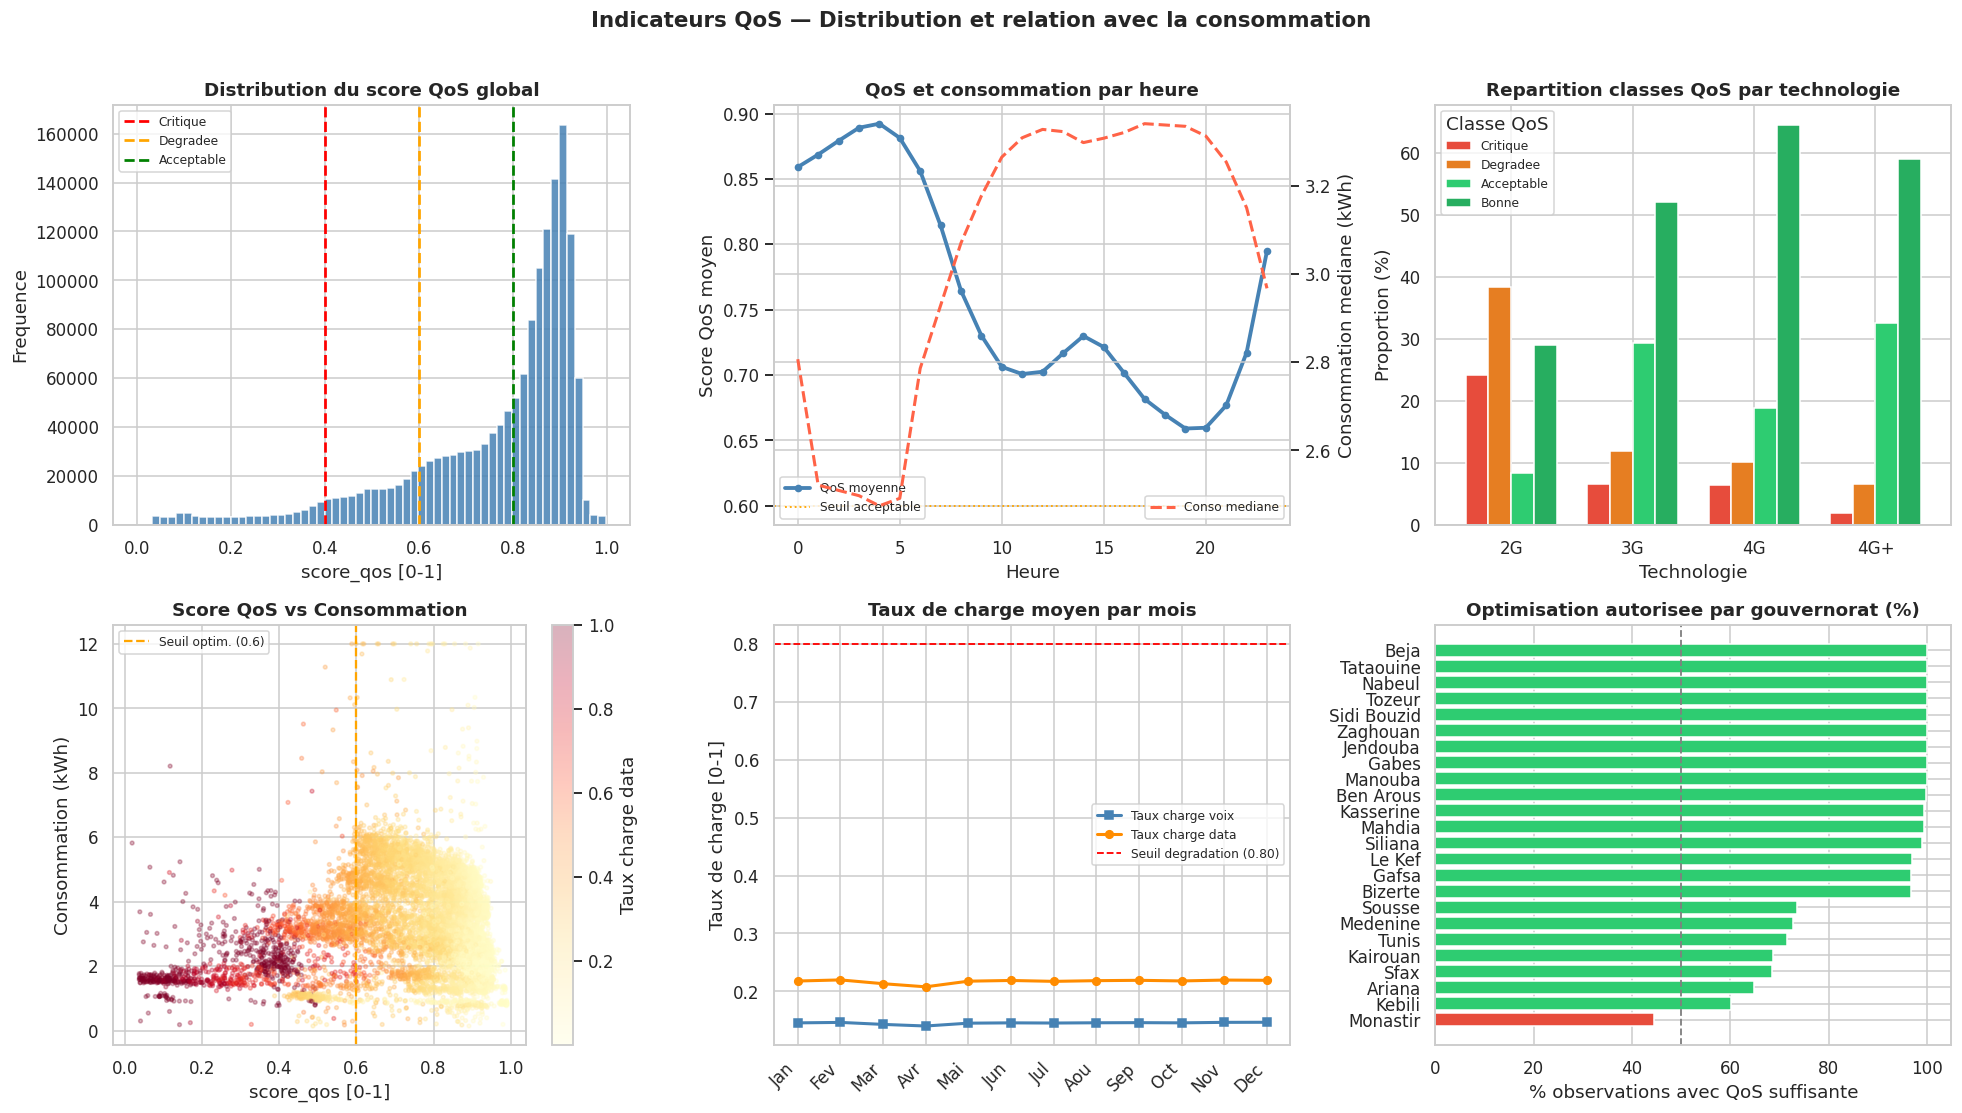

Interpretation rapide :
  Gouvernorats avec plus de marge pour optimiser :
    Beja            : 99.9% du temps
    Tataouine       : 99.9% du temps
    Nabeul          : 99.9% du temps
  Gouvernorats a surveiller en priorite :
    Monastir        : 44.4% du temps
    Kebili          : 60.1% du temps
    Ariana          : 64.7% du temps


In [18]:
# Cellule 4c — Visualisation des indicateurs QoS

# Ces graphiques confirment la coherence des indicateurs calcules et montrent
# la relation entre QoS et consommation energetique — information cle pour NB3.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Indicateurs QoS — Distribution et relation avec la consommation',
             fontsize=14, fontweight='bold', y=1.01)

samp = df.sample(min(12000, len(df)), random_state=42)

# 1. Distribution du score QoS global
axes[0, 0].hist(df['score_qos'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
for seuil, label, color in [(0.40, 'Critique', 'red'), (0.60, 'Degradee', 'orange'),
                              (0.80, 'Acceptable', 'green')]:
    axes[0, 0].axvline(seuil, color=color, lw=1.8, ls='--', label=label)
axes[0, 0].set_title('Distribution du score QoS global', fontweight='bold')
axes[0, 0].set_xlabel('score_qos [0-1]')
axes[0, 0].set_ylabel('Frequence')
axes[0, 0].legend(fontsize=8)

# 2. Score QoS moyen par heure — montre les periodes de tension
qos_h = df.groupby('heure')['score_qos'].mean()
conso_h = df.groupby('heure')['consommation_kwh'].median()
ax2b = axes[0, 1].twinx()
axes[0, 1].plot(qos_h.index, qos_h.values, color='steelblue', lw=2.5, marker='o',
                ms=4, label='QoS moyenne')
ax2b.plot(conso_h.index, conso_h.values, color='tomato', lw=2, ls='--',
          label='Conso mediane')
axes[0, 1].axhline(0.60, color='orange', lw=1.2, ls=':', label='Seuil acceptable')
axes[0, 1].set_title('QoS et consommation par heure', fontweight='bold')
axes[0, 1].set_xlabel('Heure')
axes[0, 1].set_ylabel('Score QoS moyen')
ax2b.set_ylabel('Consommation mediane (kWh)')
axes[0, 1].legend(loc='lower left', fontsize=8)
ax2b.legend(loc='lower right', fontsize=8)

# 3. Repartition des classes QoS par technologie
cross = pd.crosstab(
    df['technologie'], df['classe_qos'], normalize='index'
) * 100
colors_cls = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']
cross.plot(kind='bar', ax=axes[0, 2], color=colors_cls, width=0.75, edgecolor='white')
axes[0, 2].set_title('Repartition classes QoS par technologie', fontweight='bold')
axes[0, 2].set_xlabel('Technologie')
axes[0, 2].set_ylabel('Proportion (%)')
axes[0, 2].tick_params(axis='x', rotation=0)
axes[0, 2].legend(title='Classe QoS', fontsize=8)

# 4. Score QoS vs Consommation — relation directe utile pour NB3
sc = axes[1, 0].scatter(
    samp['score_qos'],
    samp['consommation_kwh'].clip(upper=12),
    c=samp['taux_charge_data'], cmap='YlOrRd', alpha=0.30, s=6
)
plt.colorbar(sc, ax=axes[1, 0], label='Taux charge data')
axes[1, 0].axvline(QOS_SEUIL_OPTIMISATION, color='orange', lw=1.5, ls='--',
                    label=f'Seuil optim. ({QOS_SEUIL_OPTIMISATION})')
axes[1, 0].set_title('Score QoS vs Consommation', fontweight='bold')
axes[1, 0].set_xlabel('score_qos [0-1]')
axes[1, 0].set_ylabel('Consommation (kWh)')
axes[1, 0].legend(fontsize=8)

# 5. Taux de charge voix et data par mois — saisonnalite de la QoS
charge_mois = df.groupby('mois')[['taux_charge_voix', 'taux_charge_data']].mean()
mois_lab = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
axes[1, 1].plot(charge_mois.index, charge_mois['taux_charge_voix'],
                label='Taux charge voix', color='steelblue', lw=2, marker='s', ms=5)
axes[1, 1].plot(charge_mois.index, charge_mois['taux_charge_data'],
                label='Taux charge data', color='darkorange', lw=2, marker='o', ms=5)
axes[1, 1].axhline(0.80, color='red', lw=1.2, ls='--', label='Seuil degradation (0.80)')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(mois_lab, rotation=45, ha='right')
axes[1, 1].set_title('Taux de charge moyen par mois', fontweight='bold')
axes[1, 1].set_ylabel('Taux de charge [0-1]')
axes[1, 1].legend(fontsize=8)

# 6. Proportion d'observations ou l'optimisation est autorisee par gouvernorat
optim_gov = (
    df.groupby('gouvernorat')['optimisation_qos_autorisee'].mean() * 100
).sort_values(ascending=True)
couleurs = ['#e74c3c' if v < 50 else '#2ecc71' for v in optim_gov.values]
axes[1, 2].barh(optim_gov.index, optim_gov.values, color=couleurs, edgecolor='white')
axes[1, 2].axvline(50, color='gray', lw=1.2, ls='--')
axes[1, 2].set_title('Optimisation autorisee par gouvernorat (%)', fontweight='bold')
axes[1, 2].set_xlabel('% observations avec QoS suffisante')

plt.tight_layout()
plt.show()

print('Interpretation rapide :')
top_gov = optim_gov.sort_values(ascending=False).head(3)
bot_gov = optim_gov.sort_values(ascending=True).head(3)
print('  Gouvernorats avec plus de marge pour optimiser :')
for g, v in top_gov.items():
    print(f'    {g:15s} : {v:.1f}% du temps')
print('  Gouvernorats a surveiller en priorite :')
for g, v in bot_gov.items():
    print(f'    {g:15s} : {v:.1f}% du temps')


---
## Phase 3 — Analyse Exploratoire (EDA)


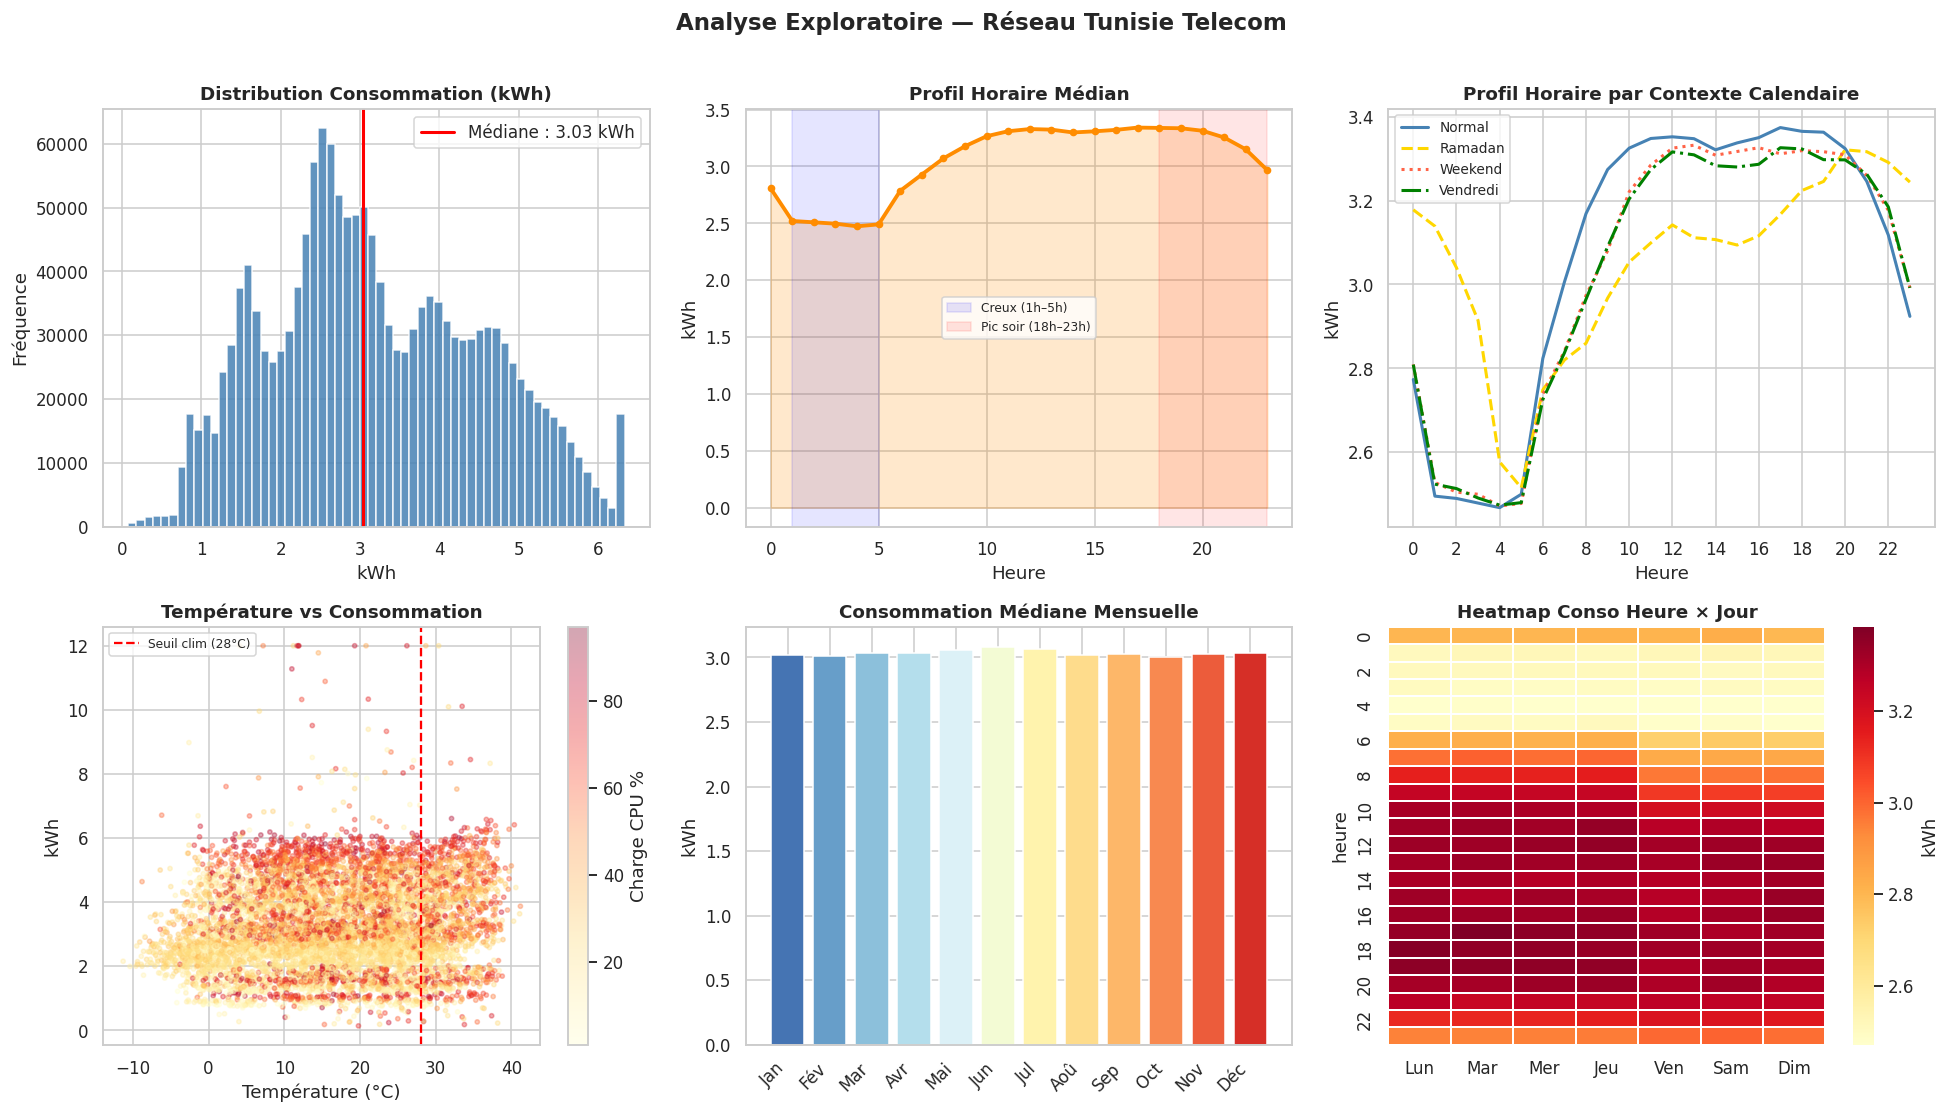

In [19]:
# Cellule 5 — EDA : 6 visualisations clés

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse Exploratoire — Réseau Tunisie Telecom',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Distribution consommation
conso_clip = df['consommation_kwh'].clip(upper=df['consommation_kwh'].quantile(0.99))
axes[0,0].hist(conso_clip, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['consommation_kwh'].median(), color='red', lw=2,
                   label=f'Médiane : {df["consommation_kwh"].median():.2f} kWh')
axes[0,0].set_title('Distribution Consommation (kWh)', fontweight='bold')
axes[0,0].set_xlabel('kWh'); axes[0,0].set_ylabel('Fréquence'); axes[0,0].legend()

# 2. Profil horaire médian
profil_h = df.groupby('heure')['consommation_kwh'].median()
axes[0,1].plot(profil_h.index, profil_h.values, color='darkorange', lw=2.5, marker='o', ms=4)
axes[0,1].fill_between(profil_h.index, profil_h.values, alpha=0.2, color='darkorange')
axes[0,1].axvspan(1, 5, alpha=0.10, color='blue', label='Creux (1h–5h)')
axes[0,1].axvspan(18, 23, alpha=0.10, color='red',  label='Pic soir (18h–23h)')
axes[0,1].set_title('Profil Horaire Médian', fontweight='bold')
axes[0,1].set_xlabel('Heure'); axes[0,1].set_ylabel('kWh'); axes[0,1].legend(fontsize=8)

# 3. Consommation par technologie
for label, masque, color, ls in [
    ('Normal',   (df['est_ramadan']==0)&(df['est_weekend']==0)&(df['est_vendredi']==0), 'steelblue', '-'),
    ('Ramadan',   df['est_ramadan']==1,   'gold',   '--'),
    ('Weekend',   df['est_weekend']==1,   'tomato', ':'),
    ('Vendredi',  df['est_vendredi']==1,  'green',  '-.'),
]:
    vals = df[masque].groupby('heure')['consommation_kwh'].median()
    axes[0,2].plot(vals.index, vals.values, label=label, color=color, ls=ls, lw=2)
axes[0,2].set_title('Profil Horaire par Contexte Calendaire', fontweight='bold')
axes[0,2].set_xlabel('Heure'); axes[0,2].set_ylabel('kWh')
axes[0,2].set_xticks(range(0, 24, 2)); axes[0,2].legend(fontsize=9)

# 4. Température vs Consommation
samp = df.sample(min(8000, len(df)), random_state=42)
sc = axes[1,0].scatter(samp['temperature_ambiante'],
                        samp['consommation_kwh'].clip(upper=12),
                        c=samp['charge_cpu_pct'], cmap='YlOrRd', alpha=0.35, s=8)
plt.colorbar(sc, ax=axes[1,0], label='Charge CPU %')
axes[1,0].axvline(28, color='red', lw=1.5, ls='--', label='Seuil clim (28°C)')
axes[1,0].set_title('Température vs Consommation', fontweight='bold')
axes[1,0].set_xlabel('Température (°C)'); axes[1,0].set_ylabel('kWh'); axes[1,0].legend(fontsize=8)

# 5. Profil mensuel
profil_m = df.groupby('mois')['consommation_kwh'].median()
mois_lab = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
axes[1,1].bar(range(1,13), profil_m.values,
              color=plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, 12)))
axes[1,1].set_xticks(range(1,13)); axes[1,1].set_xticklabels(mois_lab, rotation=45, ha='right')
axes[1,1].set_title('Consommation Médiane Mensuelle', fontweight='bold'); axes[1,1].set_ylabel('kWh')

# 6. Heatmap heure × jour
pivot = df.pivot_table(values='consommation_kwh', index='heure',
                        columns='jour_semaine', aggfunc='median')
pivot.columns = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
sns.heatmap(pivot, ax=axes[1,2], cmap='YlOrRd', annot=False,
            linewidths=0.3, cbar_kws={'label': 'kWh'})
axes[1,2].set_title('Heatmap Conso Heure × Jour', fontweight='bold')

plt.tight_layout(); plt.show()


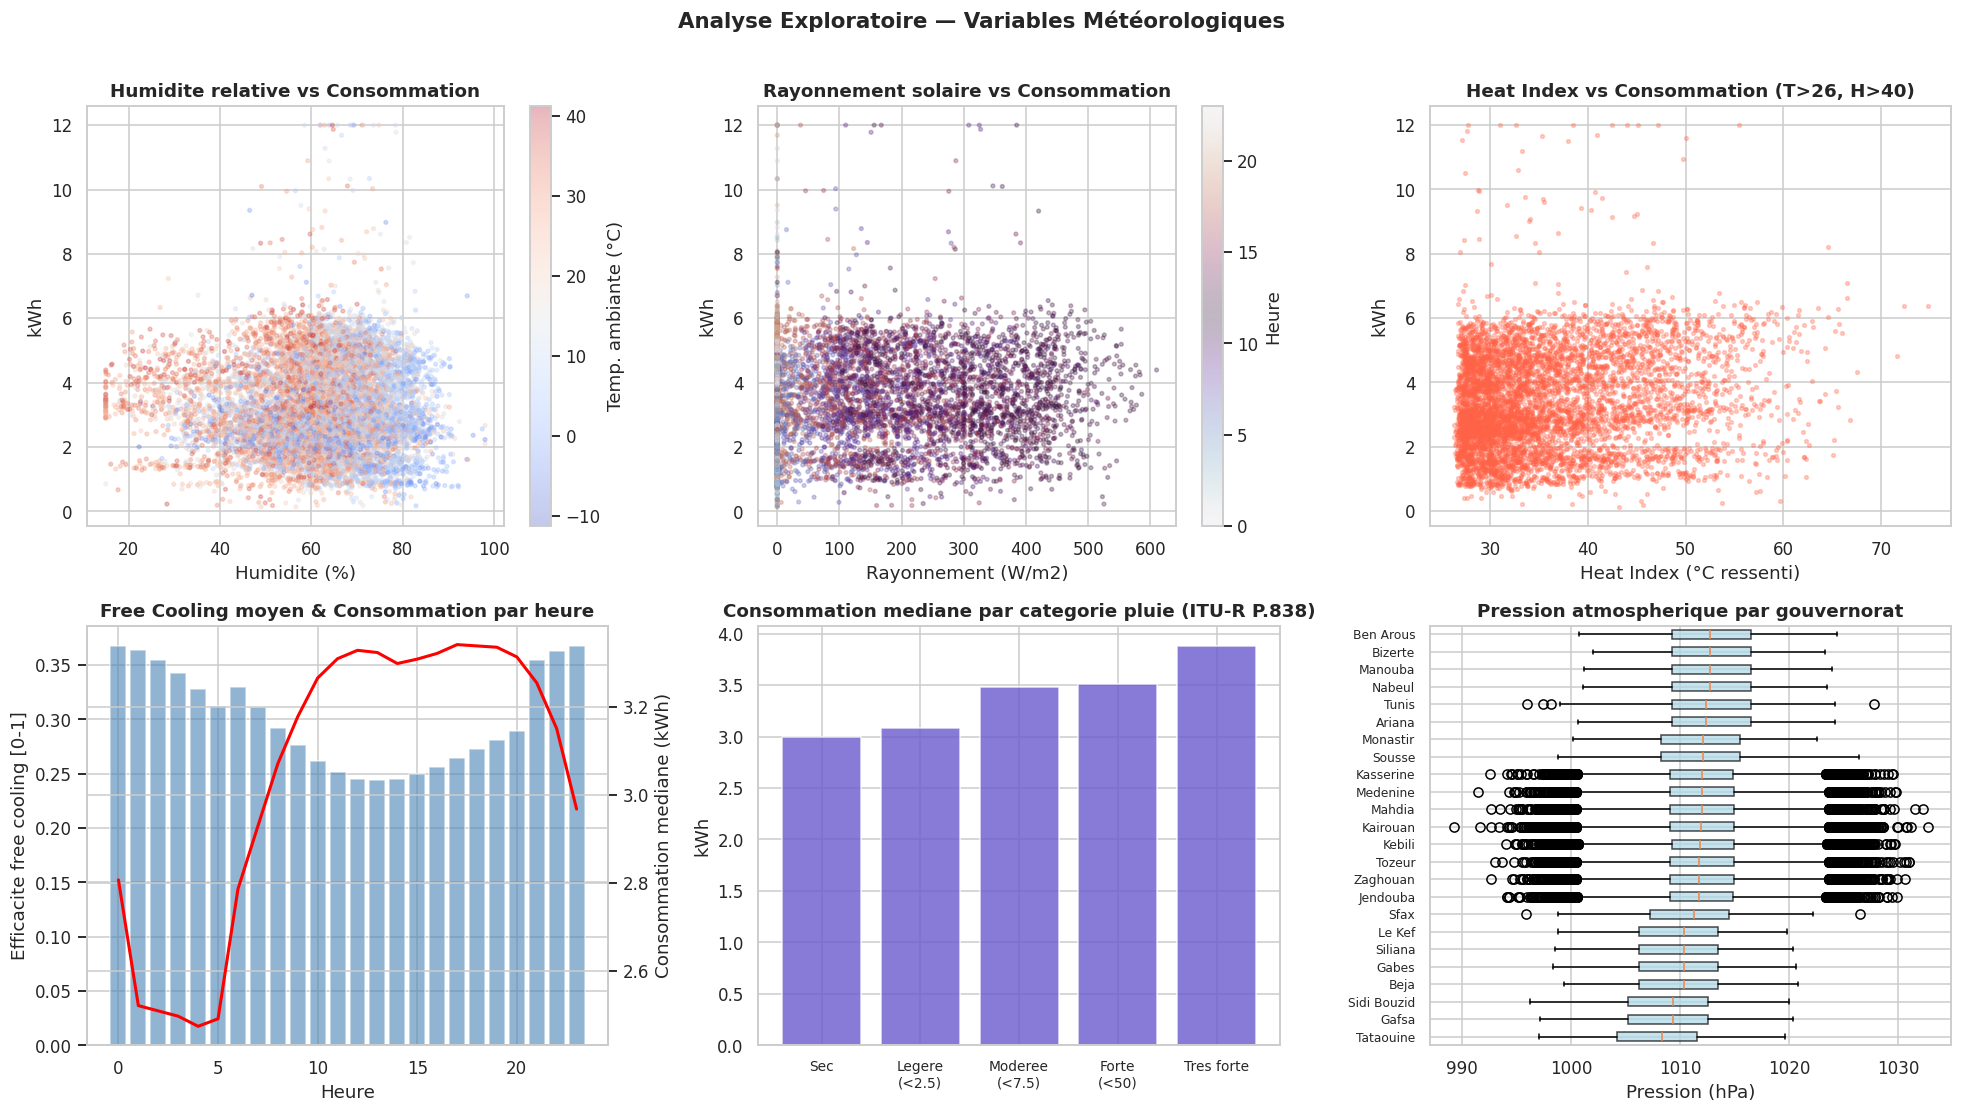

In [20]:
# Cellule 5b — EDA : visualisations des colonnes météo ajoutées
# Ces graphiques montrent la cohérence des données météo avec la consommation.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse Exploratoire — Variables Météorologiques',
             fontsize=14, fontweight='bold', y=1.01)

samp = df.sample(min(10000, len(df)), random_state=42)

# 1. Humidité vs Consommation
sc1 = axes[0, 0].scatter(
    samp['humidite_relative_pct'], samp['consommation_kwh'].clip(upper=12),
    c=samp['temperature_ambiante'], cmap='coolwarm', alpha=0.3, s=6
)
plt.colorbar(sc1, ax=axes[0, 0], label='Temp. ambiante (°C)')
axes[0, 0].set_title('Humidite relative vs Consommation', fontweight='bold')
axes[0, 0].set_xlabel('Humidite (%)')
axes[0, 0].set_ylabel('kWh')

# 2. Rayonnement solaire vs Consommation — impact de la charge thermique solaire
sc2 = axes[0, 1].scatter(
    samp['rayonnement_solaire_wm2'], samp['consommation_kwh'].clip(upper=12),
    c=samp['heure'], cmap='twilight', alpha=0.3, s=6
)
plt.colorbar(sc2, ax=axes[0, 1], label='Heure')
axes[0, 1].set_title('Rayonnement solaire vs Consommation', fontweight='bold')
axes[0, 1].set_xlabel('Rayonnement (W/m2)')
axes[0, 1].set_ylabel('kWh')

# 3. Heat index vs Consommation (uniquement quand T > 26 et H > 40)
mask_hi = (df['temperature_ambiante'] > 26) & (df['humidite_relative_pct'] > 40)
samp_hi = df[mask_hi].sample(min(6000, mask_hi.sum()), random_state=42)
axes[0, 2].scatter(
    samp_hi['heat_index'], samp_hi['consommation_kwh'].clip(upper=12),
    alpha=0.3, s=6, color='tomato'
)
axes[0, 2].set_title('Heat Index vs Consommation (T>26, H>40)', fontweight='bold')
axes[0, 2].set_xlabel('Heat Index (°C ressenti)')
axes[0, 2].set_ylabel('kWh')

# 4. Efficacite free cooling par heure
fc_h = df.groupby('heure')['efficacite_free_cooling'].mean()
conso_h = df.groupby('heure')['consommation_kwh'].median()
ax_fc = axes[1, 0]
ax_fc2 = ax_fc.twinx()
ax_fc.bar(fc_h.index, fc_h.values, color='steelblue', alpha=0.6, label='Free Cooling moyen')
ax_fc2.plot(conso_h.index, conso_h.values, color='red', lw=2, label='Conso mediane')
ax_fc.set_title('Free Cooling moyen & Consommation par heure', fontweight='bold')
ax_fc.set_xlabel('Heure')
ax_fc.set_ylabel('Efficacite free cooling [0-1]')
ax_fc2.set_ylabel('Consommation mediane (kWh)')

# 5. Consommation mediane par categorie de pluie (ITU-R P.838)
labels_pluie = ['Sec', 'Legere\n(<2.5)', 'Moderee\n(<7.5)', 'Forte\n(<50)', 'Tres forte']
conso_pluie = df.groupby('categorie_pluie')['consommation_kwh'].median()
axes[1, 1].bar(range(len(conso_pluie)), conso_pluie.values, color='slateblue', alpha=0.8)
axes[1, 1].set_xticks(range(len(conso_pluie)))
axes[1, 1].set_xticklabels(labels_pluie[:len(conso_pluie)], fontsize=9)
axes[1, 1].set_title('Consommation mediane par categorie pluie (ITU-R P.838)', fontweight='bold')
axes[1, 1].set_ylabel('kWh')

# 6. Distribution de la pression atmospherique par gouvernorat
gov_order = df.groupby('gouvernorat')['pression_atmospherique_hpa'].median().sort_values().index
df_box = [df[df['gouvernorat'] == g]['pression_atmospherique_hpa'].dropna().values
          for g in gov_order]
axes[1, 2].boxplot(df_box, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1, 2].set_yticks(range(1, len(gov_order)+1))
axes[1, 2].set_yticklabels(gov_order, fontsize=8)
axes[1, 2].set_title('Pression atmospherique par gouvernorat', fontweight='bold')
axes[1, 2].set_xlabel('Pression (hPa)')

plt.tight_layout()
plt.show()


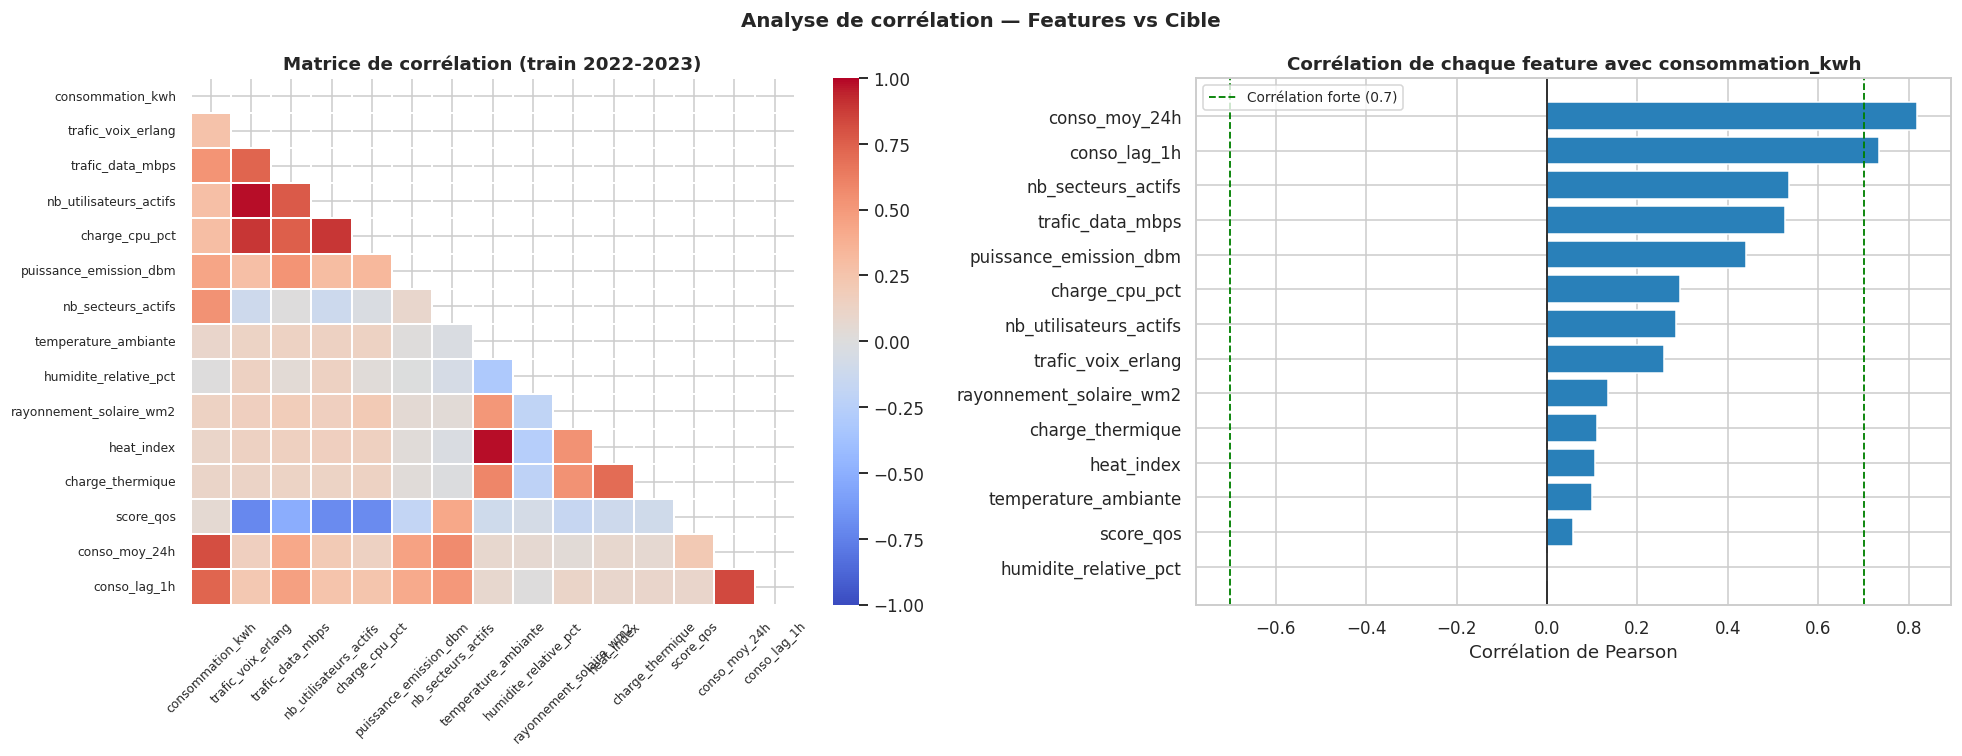


Paires de features fortement colinéaires (|r| > 0.90) :
  temperature_ambiante           ↔ heat_index                     : r = 0.979
  trafic_voix_erlang             ↔ nb_utilisateurs_actifs         : r = 0.979

  → Ces paires peuvent être réduites sans perte de performance.
    Stratégie recommandée : conserver celle qui a la plus forte corrélation avec la cible.

Top 10 features corrélées avec consommation_kwh :
  conso_moy_24h                       : |r| = 0.818
  conso_lag_1h                        : |r| = 0.733
  nb_secteurs_actifs                  : |r| = 0.534
  trafic_data_mbps                    : |r| = 0.527
  puissance_emission_dbm              : |r| = 0.440
  charge_cpu_pct                      : |r| = 0.293
  nb_utilisateurs_actifs              : |r| = 0.285
  trafic_voix_erlang                  : |r| = 0.259
  rayonnement_solaire_wm2             : |r| = 0.134
  charge_thermique                    : |r| = 0.111


In [21]:
# Cellule 5c — Corrélations et sélection de features

# 1. Heatmap de corrélation des features numériques clés
COLS_CORR = [
    'consommation_kwh',
    'trafic_voix_erlang', 'trafic_data_mbps', 'nb_utilisateurs_actifs',
    'charge_cpu_pct', 'puissance_emission_dbm', 'nb_secteurs_actifs',
    'temperature_ambiante', 'humidite_relative_pct', 'rayonnement_solaire_wm2',
    'heat_index', 'charge_thermique', 'score_qos',
    'conso_moy_24h', 'conso_lag_1h',
]

corr = df[df['annee'] < 2024][COLS_CORR].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Analyse de corrélation — Features vs Cible', fontsize=13, fontweight='bold')

# Heatmap complète
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=axes[0],
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=False, linewidths=0.3,
    xticklabels=COLS_CORR, yticklabels=COLS_CORR
)
axes[0].set_title('Matrice de corrélation (train 2022-2023)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Corrélations avec la cible uniquement — classées
corr_target = corr['consommation_kwh'].drop('consommation_kwh').sort_values()
colors_bar = ['#e74c3c' if v < 0 else '#2980b9' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(0.7,  color='green', lw=1.2, ls='--', label='Corrélation forte (0.7)')
axes[1].axvline(-0.7, color='green', lw=1.2, ls='--')
axes[1].set_title('Corrélation de chaque feature avec consommation_kwh', fontweight='bold')
axes[1].set_xlabel('Corrélation de Pearson')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/eda_correlations.png', dpi=110, bbox_inches='tight')
plt.show()

# 2. Détection des features colinéaires (|corr| > 0.90 entre features)
print('\nPaires de features fortement colinéaires (|r| > 0.90) :')
corr_feat = corr.drop(columns='consommation_kwh').drop(index='consommation_kwh')
pairs_colineaires = []
for i in range(len(corr_feat.columns)):
    for j in range(i+1, len(corr_feat.columns)):
        val = corr_feat.iloc[i, j]
        if abs(val) > 0.90:
            pairs_colineaires.append((corr_feat.columns[i], corr_feat.columns[j], val))

if pairs_colineaires:
    for f1, f2, v in sorted(pairs_colineaires, key=lambda x: -abs(x[2])):
        print(f'  {f1:<30} ↔ {f2:<30} : r = {v:.3f}')
    print('\n  → Ces paires peuvent être réduites sans perte de performance.')
    print('    Stratégie recommandée : conserver celle qui a la plus forte corrélation avec la cible.')
else:
    print('  Aucune colinéarité forte détectée entre les features sélectionnées.')

# 3. Top 10 features les plus corrélées avec la cible
print('\nTop 10 features corrélées avec consommation_kwh :')
top10 = corr['consommation_kwh'].drop('consommation_kwh').abs().sort_values(ascending=False).head(10)
for feat, val in top10.items():
    print(f'  {feat:<35} : |r| = {val:.3f}')

---
## Phase 4 — Modélisation : Comparaison de 7 Modèles Supervisés

### Définition des features et de la cible


In [22]:
# Cellule 6 — Définition des features

FEATURES = [
    # Trafic réseau
    'trafic_voix_erlang', 'trafic_data_mbps', 'nb_utilisateurs_actifs',
    # État système
    'charge_cpu_pct', 'nb_secteurs_actifs', 'puissance_emission_dbm',
    # Environnement — température et features météo (ETSI EN 300 019, ITU-T L.1311)
    'temperature_ambiante', 'charge_thermique', 'trafic_x_temp', 'charge_cpu_x_secteurs',
    # Colonnes météo brutes
    'humidite_relative_pct', 'vitesse_vent_ms', 'rayonnement_solaire_wm2',
    'precipitation_mmh', 'pression_atmospherique_hpa', 'indice_uv',
    # Features météo dérivées (heat index, free cooling, charge solaire)
    'heat_index', 'efficacite_free_cooling', 'charge_thermique_solaire',
    'est_pluie', 'categorie_pluie',
    # Temps cyclique
    'mois_annee',
    'heure_sin', 'heure_cos', 'jour_sin', 'jour_cos', 'mois_sin', 'mois_cos',
    # Contexte tunisien
    'est_weekend', 'est_vendredi', 'est_ramadan', 'est_ferie',
    # Catégorielles encodées
    'station_enc',
    'technologie_enc', 'type_zone_enc', 'gouvernorat_enc',
    # Features construites
    'charge_par_secteur', 'efficacite_spectrale', 'intensite_trafic',
    'conso_moy_24h', 'conso_moy_48h', 'conso_moy_7j',
    'conso_moy_station',
    # Lags temporels
    'conso_lag_1h', 'conso_lag_2h', 'conso_lag_3h', 'tendance_3h',
    # Indicateurs QoS — permettent au modele d'apprendre la relation
    # entre niveau de service et consommation (reuse dans NB2 et NB3)
    'taux_charge_voix', 'taux_charge_data',
    'stress_radio', 'score_qualite_radio', 'score_qos',
]

FEATURES_V2 = list(dict.fromkeys(
    FEATURES +
    [f'conso_lag_{i}h' for i in range(1, 7)] +
    [f'cpu_lag_{i}h'   for i in range(1, 7)] +
    ['conso_lag_24h', 'conso_lag_48h', 'conso_lag_168h', 
     'duree_anomalie']
))

TARGET = 'consommation_kwh'

# Le nombre de features V1 augmente de 11 (6 météo brutes + 5 dérivées)
print(f'Features V1 : {len(FEATURES)}')
print(f'Features V2 : {len(FEATURES_V2)} (enrichies)')


Features V1 : 52
Features V2 : 65 (enrichies)


In [23]:
# Cellule 7 — Préparation des jeux train / test

df_train_full = df[df['annee'] < 2024].copy()
df_test_full  = df[df['annee'] == 2024].copy()

df_train = df_train_full.sort_values(['station_id', 'timestamp']).copy()

df_test  = (df_test_full
             .sort_values(['station_id', 'timestamp'])
             .copy())

X_train = df_train[FEATURES_V2].values
y_train = df_train[TARGET].values

X_test  = df_test[FEATURES_V2].values
y_test  = df_test[TARGET].values

print(f'\nTrain 2022–2023 : {len(df_train):>10,} lignes')
print(f'Test  2024      : {len(df_test):>10,} lignes')
print(f'Contenu test : Ramadan={df_test["est_ramadan"].sum():,} | Été={df_test[df_test["mois"].between(6,9)].shape[0]:,} | Fériés={df_test["est_ferie"].sum():,}')



Train 2022–2023 :  1,051,315 lignes
Test  2024      :    525,706 lignes
Contenu test : Ramadan=41,688 | Été=175,812 | Fériés=18,673


In [24]:
# Cellule 8 — Entraînement des 7 modèles supervisés

# Imputer pour les modèles qui ne gèrent pas les NaN
imputer_base = SimpleImputer(strategy='mean')
X_train_imp  = imputer_base.fit_transform(X_train)
X_test_imp   = imputer_base.transform(X_test)

params_lgbm = dict(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 7,        # ← 6 → 7
    num_leaves        = 50,       # ← 31 → 50
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 30,       # ← 50 → 30
    min_split_gain    = 0.05,     # ← 0.1 → 0.05
    reg_alpha         = 0.3,      # ← 0.5 → 0.3
    reg_lambda        = 1.5,      # ← 2.0 → 1.5
    n_jobs=-1, random_state=42, verbose=-1
)

resultats_modeles = {}

def evaluer(nom, y_true, y_pred, t_elapsed):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    rp   = rmse / y_true.mean() * 100
    resultats_modeles[nom] = {'r2': r2, 'mae': mae, 'rmse': rmse, 'rmse_pct': rp, 'temps': t_elapsed}
    ok = 'PASS' if r2 >= 0.80 else 'FAIL'
    print(f'  {ok}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f} ({rp:.1f}%)  t={t_elapsed:.1f}s')
    return r2, rmse, mae

# 1. Régression Linéaire (baseline)
print('Modèle 1 — Régression Linéaire (baseline)')
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_imp, y_train)
evaluer('Régression Linéaire', y_test, lr.predict(X_test_imp), time.time()-t0)

# 2. Ridge Regression
print('Modèle 2 — Ridge Regression (L2 régularisée)')
t0 = time.time()
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_imp, y_train)
evaluer('Ridge Regression', y_test, ridge.predict(X_test_imp), time.time()-t0)

# 3. Random Forest
print('Modèle 3 — Random Forest')
t0 = time.time()
rf = RandomForestRegressor(n_estimators=150, max_depth=20, min_samples_leaf=5,
                            max_features=0.7, n_jobs=-1, random_state=42)
rf.fit(X_train_imp, y_train)
evaluer('Random Forest', y_test, rf.predict(X_test_imp), time.time()-t0)

# 4. Gradient Boosting sklearn
print('Modèle 4 — Gradient Boosting (sklearn)')
t0 = time.time()
gb_sk = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                                   subsample=0.8, max_features=0.7, min_samples_leaf=10,
                                   n_iter_no_change=20, validation_fraction=0.10, random_state=42)
gb_sk.fit(X_train_imp, y_train)
evaluer('Gradient Boosting', y_test, gb_sk.predict(X_test_imp), time.time()-t0)

# 5. Extra Trees
print('Modèle 5 — Extra Trees Regressor')
t0 = time.time()
et = ExtraTreesRegressor(n_estimators=150, max_depth=20, min_samples_leaf=5,
                          max_features=0.7, n_jobs=-1, random_state=42)
et.fit(X_train_imp, y_train)
evaluer('Extra Trees', y_test, et.predict(X_test_imp), time.time()-t0)

# 6. XGBoost
print('Modèle 6 — XGBoost')
t0 = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                               subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                               reg_lambda=1.0, n_jobs=-1, random_state=42, verbosity=0)
xgb_model.fit(X_train_imp, y_train)
evaluer('XGBoost', y_test, xgb_model.predict(X_test_imp), time.time()-t0)

# 7. LightGBM
print('Modèle 7 — LightGBM (modèle principal)')
t0 = time.time()

gb = lgb.LGBMRegressor(**{**params_lgbm, 'n_estimators': 500})
gb.fit(X_train, y_train)

r2_gb, rmse_gb, mae_gb = evaluer('LightGBM', y_test, gb.predict(X_test), time.time()-t0)
y_pred_gb = gb.predict(X_test)

Modèle 1 — Régression Linéaire (baseline)
  FAIL  R²=0.6955  MAE=0.4011  RMSE=0.7942 (24.5%)  t=3.5s
Modèle 2 — Ridge Regression (L2 régularisée)
  FAIL  R²=0.6956  MAE=0.4010  RMSE=0.7940 (24.5%)  t=0.6s
Modèle 3 — Random Forest
  PASS  R²=0.8007  MAE=0.2519  RMSE=0.6424 (19.9%)  t=3191.1s
Modèle 4 — Gradient Boosting (sklearn)
  PASS  R²=0.8002  MAE=0.2525  RMSE=0.6433 (19.9%)  t=5755.8s
Modèle 5 — Extra Trees Regressor
  PASS  R²=0.8009  MAE=0.2519  RMSE=0.6422 (19.9%)  t=620.5s
Modèle 6 — XGBoost
  PASS  R²=0.8005  MAE=0.2506  RMSE=0.6428 (19.9%)  t=47.7s
Modèle 7 — LightGBM (modèle principal)
  PASS  R²=0.8010  MAE=0.2504  RMSE=0.6420 (19.8%)  t=71.8s


In [25]:
# Cellule 8_baseline — Baseline naïve (persistance & moyenne)
# Objectif : mesurer le gain réel apporté par le ML.
# Un modèle qui se contente de répéter la valeur précédente (persistance t-1) 
# minimale que tout modèle ML doit dépasser clairement.

print('BASELINES NAÏVES — référence minimale')

# Baseline : Persistance (prédire y_test[t] = y_test[t-1]) 
# On décale y_test d'un pas. La première valeur n'a pas de précédent
# on la remplace par la moyenne du train pour éviter les NaN.
y_persist = np.concatenate([[y_train.mean()], y_test[:-1]])

r2_persist   = r2_score(y_test, y_persist)
mae_persist  = mean_absolute_error(y_test, y_persist)
rmse_persist = np.sqrt(mean_squared_error(y_test, y_persist))
rp_persist   = rmse_persist / y_test.mean() * 100

print(f'\n  Persistance (y_pred = y[t-1])')
print(f'    R²   = {r2_persist:.4f}')
print(f'    MAE  = {mae_persist:.4f} kWh')
print(f'    RMSE = {rmse_persist:.4f} kWh  ({rp_persist:.1f}%)')

# Ajout dans le tableau comparatif 
resultats_modeles['Baseline Persistance'] = {
    'r2': r2_persist, 'mae': mae_persist,
    'rmse': rmse_persist, 'rmse_pct': rp_persist, 'temps': 0.0
}

print(f'\n   Gain LightGBM vs Persistance : ΔR² = {r2_gb - r2_persist:+.4f}')


BASELINES NAÏVES — référence minimale

  Persistance (y_pred = y[t-1])
    R²   = 0.4664
    MAE  = 0.5154 kWh
    RMSE = 1.0513 kWh  (32.5%)

   Gain LightGBM vs Persistance : ΔR² = +0.3346


In [26]:
# Cellule 8b — Vérification overfitting : R² train vs test
y_pred_train_gb = gb.predict(X_train)
r2_train = r2_score(y_train, y_pred_train_gb)
r2_test  = r2_score(y_test,  gb.predict(X_test))
gap      = r2_train - r2_test

print('Analyse overfitting — LightGBM')
print(f'  R² train : {r2_train:.4f}')
print(f'  R² test  : {r2_test:.4f}')
print(f'  Gap      : {gap:.4f}  → {"Acceptable (<= 0.05)" if gap <= 0.05 else "Gap élevé (>0.05) — vérifier overfitting"}')

Analyse overfitting — LightGBM
  R² train : 0.8060
  R² test  : 0.8010
  Gap      : 0.0050  → Acceptable (<0.05)


In [27]:
# Analyse du drift temporel train → test
print("Drift temporel 2022-2023 → 2024 :")
for col in ['consommation_kwh', 'trafic_data_mbps', 'charge_cpu_pct']:
    m_train = df[df['annee'] < 2024][col].mean()
    m_test  = df[df['annee'] == 2024][col].mean()
    print(f"  {col:<30} : train={m_train:.3f}  test={m_test:.3f}  Δ={((m_test-m_train)/m_train*100):+.1f}%")
print("\n→ Le gap R² résiduel s'explique par ce drift naturel de distribution,")
print("  inhérent à toute prédiction sur série temporelle longue.")

Drift temporel 2022-2023 → 2024 :
  consommation_kwh               : train=3.234  test=3.235  Δ=+0.0%
  trafic_data_mbps               : train=49.543  test=49.544  Δ=+0.0%
  charge_cpu_pct                 : train=33.220  test=33.220  Δ=-0.0%

→ Le gap R² résiduel s'explique par ce drift naturel de distribution,
  inhérent à toute prédiction sur série temporelle longue.


In [28]:
# Cellule 9 — Tableau comparatif des 7 modèles

print(' \n COMPARAISON DES 7 MODÈLES — JEU DE TEST 2024')
print(f"  {'Modèle':<26} {'R²':>8}  {'MAE':>8}  {'RMSE%':>8}  {'Temps':>8}  {'KPI R²≥0.80':>12}")
for nom, res in sorted(resultats_modeles.items(), key=lambda x: -x[1]['r2']):
    ok = 'ATTEINT' if res['r2'] >= 0.80 else 'MANQUÉ'
    print(f"  {nom:<26} {res['r2']:>8.4f}  {res['mae']:>8.4f}  {res['rmse_pct']:>7.1f}%  {res['temps']:>7.0f}s  {ok:>12}")
print('  Modèle retenu : LightGBM')
print('  Justification : meilleur R², RMSE minimal, régularisation L1/L2, vitesse élevée')

# Sauvegarde JSON
with open('outputs/resultats_modeles.json', 'w') as f:
    json.dump(resultats_modeles, f, indent=2)
print('\n outputs/resultats_modeles.json sauvegardé')


 
 COMPARAISON DES 7 MODÈLES — JEU DE TEST 2024
  Modèle                           R²       MAE     RMSE%     Temps   KPI R²≥0.80
  LightGBM                     0.8010    0.2504     19.8%       72s       ATTEINT
  Extra Trees                  0.8009    0.2519     19.9%      621s       ATTEINT
  Random Forest                0.8007    0.2519     19.9%     3191s       ATTEINT
  XGBoost                      0.8005    0.2506     19.9%       48s       ATTEINT
  Gradient Boosting            0.8002    0.2525     19.9%     5756s       ATTEINT
  Ridge Regression             0.6956    0.4010     24.5%        1s        MANQUÉ
  Régression Linéaire          0.6955    0.4011     24.5%        3s        MANQUÉ
  Baseline Persistance         0.4664    0.5154     32.5%        0s        MANQUÉ
  Modèle retenu : LightGBM
  Justification : meilleur R², RMSE minimal, régularisation L1/L2, vitesse élevée

 outputs/resultats_modeles.json sauvegardé


In [30]:
# Cellule 10 — Modèles quantile (intervalles de prédiction)

print('Entraînement modèles quantile Q10 et Q90 (régression quantile, pinball loss)...')
_qp = dict(n_estimators=300, learning_rate=0.05,
           max_depth=6, num_leaves=31,
           subsample=0.8, colsample_bytree=0.8,
           min_child_samples=50, min_split_gain=0.1,
           reg_alpha=0.5, reg_lambda=2.0,
           n_jobs=-1, random_state=42, verbose=-1)

t0 = time.time()
gb_q10 = lgb.LGBMRegressor(objective='quantile', alpha=0.10, **_qp)
gb_q10.fit(X_train, y_train)
gb_q90 = lgb.LGBMRegressor(objective='quantile', alpha=0.90, **_qp)
gb_q90.fit(X_train, y_train)
print(f'  Durée : {time.time()-t0:.0f}s')

y_pred_q10 = gb_q10.predict(X_test)
y_pred_q90 = gb_q90.predict(X_test)
couverture = ((y_test >= y_pred_q10) & (y_test <= y_pred_q90)).mean() * 100
print(f'  Couverture [Q10,Q90] : {couverture:.1f}%  (cible théorique = 80%)')
print(f'  Largeur moy. intervalle : {(y_pred_q90 - y_pred_q10).mean():.3f} kWh')


Entraînement modèles quantile Q10 et Q90 (régression quantile, pinball loss)...
  Durée : 90s
  Couverture [Q10,Q90] : 78.9%  (cible théorique = 80%)
  Largeur moy. intervalle : 0.597 kWh


In [31]:
# CELLULE 10b

# 1. Calculer les lags UNIQUEMENT sur df_train, jamais sur df complet
df_train_cv = df[df['annee'] < 2024].copy().sort_values('timestamp')
df_test_cv  = df[df['annee'] == 2024].copy().sort_values('timestamp')

LAG_COLS_NEW = []

# Lags simples (shift propre, pas de leakage)
for lag_h in [1, 2, 3, 24, 48, 168]:
    col = f'lag_{lag_h}h'
    df_train_cv[col] = (df_train_cv.groupby('station_id')['consommation_kwh']
                                   .shift(lag_h))
    LAG_COLS_NEW.append(col)

# Rolling sur train uniquement
for w in [6, 24, 168]:
    col = f'roll_mean_{w}h'
    df_train_cv[col] = (df_train_cv.groupby('station_id')['consommation_kwh']
                                   .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean()))
    LAG_COLS_NEW.append(col)

df_train_cv['roll_std_24h'] = (df_train_cv.groupby('station_id')['consommation_kwh']
                                           .transform(lambda x: x.shift(1).rolling(24, min_periods=1).std()))
LAG_COLS_NEW.append('roll_std_24h')

df_train_cv.dropna(subset=LAG_COLS_NEW, inplace=True)

# Éviter doublons : enlever les lags déjà présents dans FEATURES_V2
FEATURES_CV = list(dict.fromkeys(FEATURES_V2 + LAG_COLS_NEW))
# (dict.fromkeys supprime les doublons en gardant l'ordre)

X_cv = df_train_cv[FEATURES_CV].values
y_cv = df_train_cv['consommation_kwh'].values

print(f'Features CV : {len(FEATURES_CV)} (dont {len(LAG_COLS_NEW)} nouveaux lags)')
print(f'Train CV    : {X_cv.shape}')

# 2. Cross-validation temporelle 
tscv = TimeSeriesSplit(n_splits=5, gap=24) 
cv_r2, cv_rmse = [], []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_cv), 1):
    Xtr, Xva = X_cv[tr_idx], X_cv[va_idx]
    ytr, yva = y_cv[tr_idx], y_cv[va_idx]

    m = lgb.LGBMRegressor(**{**params_lgbm,
                              'n_estimators': 300,
                              'num_leaves': 63,
                              'learning_rate': 0.03})
    m.fit(Xtr, ytr,
          eval_set=[(Xva, yva)],
          callbacks=[lgb.early_stopping(80, verbose=False),
                     lgb.log_evaluation(0)])

    pva = m.predict(Xva)
    cv_r2.append(r2_score(yva, pva))
    cv_rmse.append(np.sqrt(mean_squared_error(yva, pva)))
    print(f'  Fold {fold}: R²={cv_r2[-1]:.4f}  RMSE={cv_rmse[-1]:.4f}  '
          f'(arbres: {m.best_iteration_ or 2000})')

print(f'\n  R² moyen tous folds  : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}')
print(f'  R² stable (folds 2-6): {np.mean(cv_r2[1:]):.4f} ± {np.std(cv_r2[1:]):.4f}')

Features CV : 75 (dont 10 nouveaux lags)
Train CV    : (1013096, 75)
  Fold 1: R²=0.7953  RMSE=0.6614  (arbres: 193)
  Fold 2: R²=0.7942  RMSE=0.6463  (arbres: 299)
  Fold 3: R²=0.7929  RMSE=0.6449  (arbres: 300)
  Fold 4: R²=0.7938  RMSE=0.6655  (arbres: 298)
  Fold 5: R²=0.7953  RMSE=0.6453  (arbres: 300)

  R² moyen tous folds  : 0.7943 ± 0.0009
  R² stable (folds 2-6): 0.7941 ± 0.0009


---
## Phase 5 — Évaluation & Interprétabilité SHAP


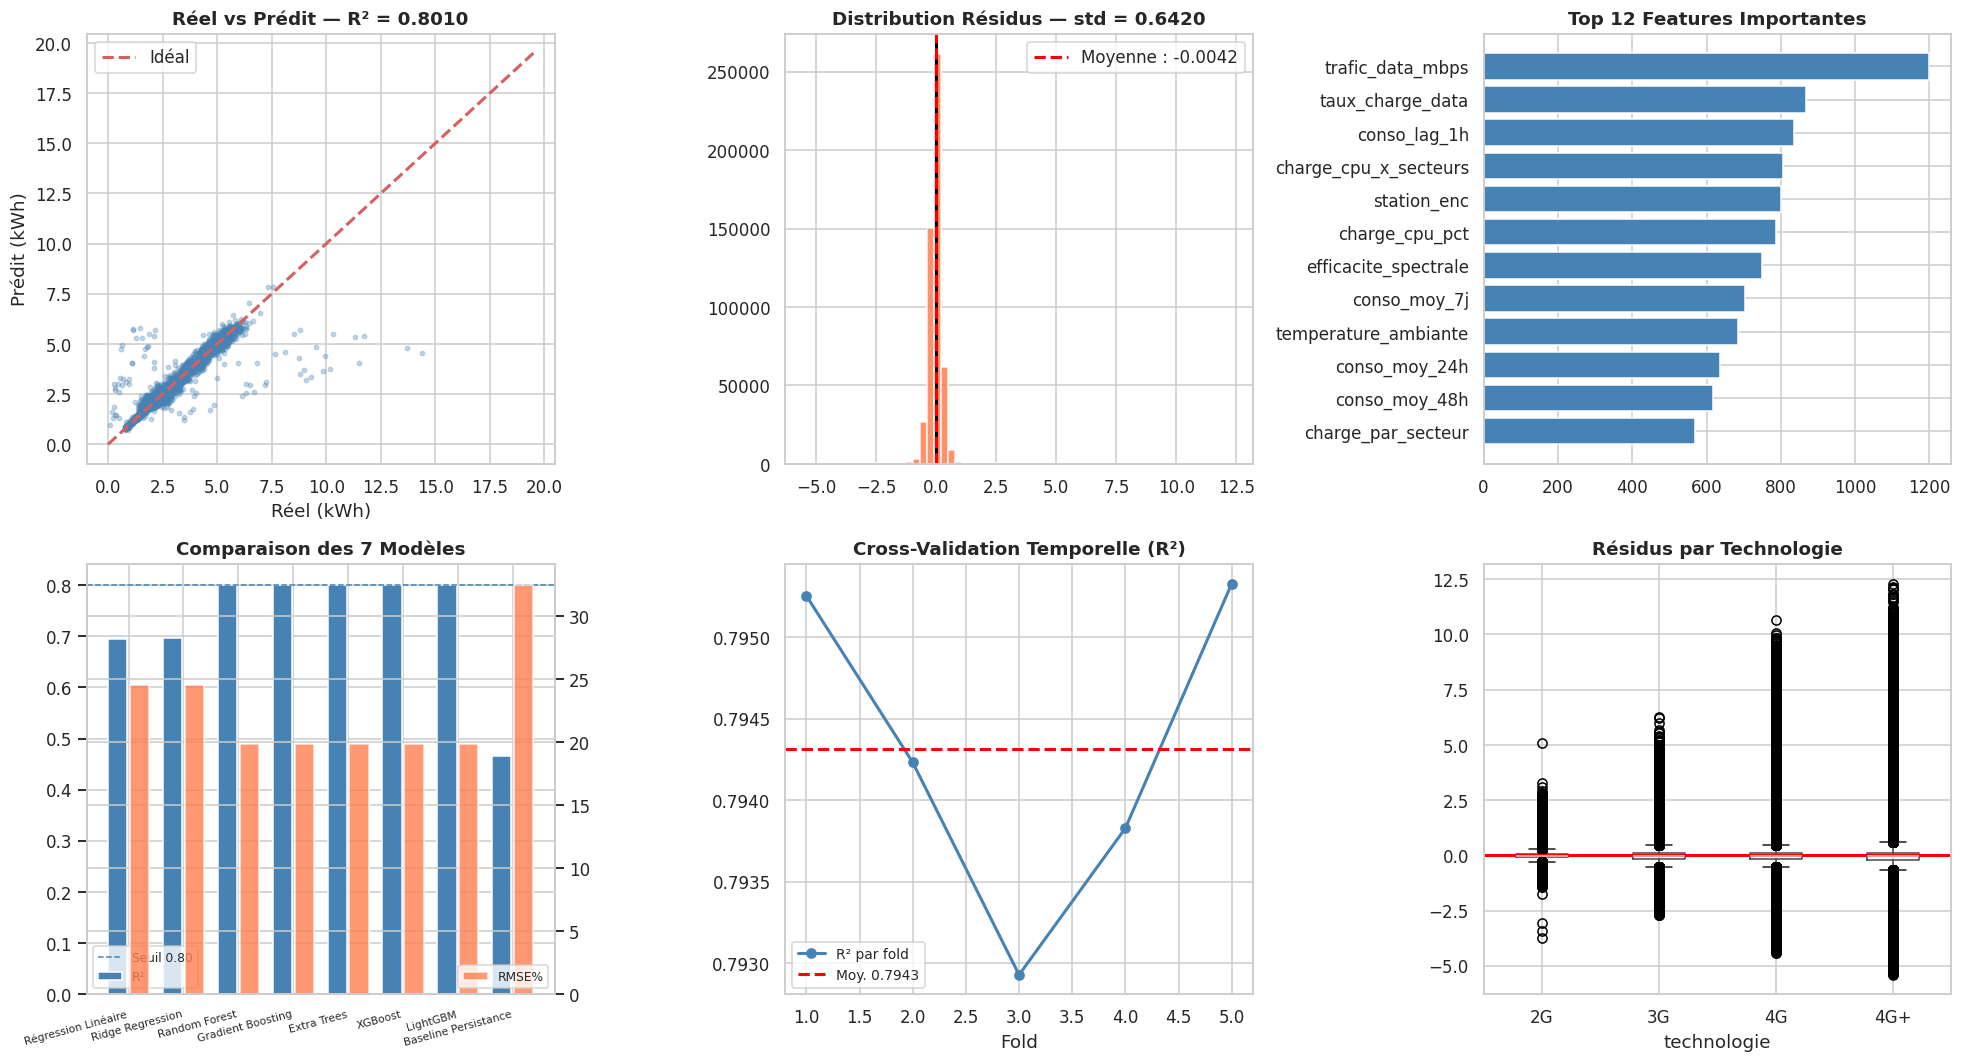

In [49]:
# Cellule 11 — Visualisation des performances LightGBM

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Performance du Modèle LightGBM — Jeu de Test 2024',
             fontsize=14, fontweight='bold')

# 1. Réel vs Prédit
n_s   = min(3000, len(y_test))
idx_s = np.random.choice(len(y_test), n_s, replace=False)
axes[0,0].scatter(y_test[idx_s], y_pred_gb[idx_s], alpha=0.3, s=8, color='steelblue')
lim = max(y_test.max(), y_pred_gb.max()) * 1.05
axes[0,0].plot([0, lim], [0, lim], 'r--', lw=2, label='Idéal')
axes[0,0].set_xlabel('Réel (kWh)'); axes[0,0].set_ylabel('Prédit (kWh)')
axes[0,0].set_title(f'Réel vs Prédit — R² = {r2_gb:.4f}', fontweight='bold')
axes[0,0].legend()

# 2. Distribution des résidus
residus = y_test - y_pred_gb
axes[0,1].hist(residus, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].axvline(0, color='black', lw=2)
axes[0,1].axvline(residus.mean(), color='red', lw=2, ls='--',
                   label=f'Moyenne : {residus.mean():.4f}')
axes[0,1].set_title(f'Distribution Résidus — std = {residus.std():.4f}', fontweight='bold')
axes[0,1].legend()

# 3. Importance features (top 12)
imp = pd.Series(gb.feature_importances_, index=FEATURES_V2).sort_values(ascending=False)
axes[0,2].barh(imp.index[:12][::-1], imp.values[:12][::-1], color='steelblue')
axes[0,2].set_title('Top 12 Features Importantes', fontweight='bold')

# 4. Comparaison des 7 modèles
noms_comp = list(resultats_modeles.keys())
r2_comp   = [resultats_modeles[n]['r2']       for n in noms_comp]
rmse_comp = [resultats_modeles[n]['rmse_pct'] for n in noms_comp]
x = np.arange(len(noms_comp))
axes[1,0].bar(x - 0.2, r2_comp,   0.35, label='R²',    color='steelblue')
ax2 = axes[1,0].twinx()
ax2.bar(x + 0.2,  rmse_comp, 0.35, label='RMSE%', color='coral', alpha=0.8)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(noms_comp, rotation=15, ha='right', fontsize=7)
axes[1,0].axhline(0.80, color='steelblue', ls='--', lw=1, label='Seuil 0.80')
axes[1,0].set_title('Comparaison des 7 Modèles', fontweight='bold')
axes[1,0].legend(loc='lower left', fontsize=8)
ax2.legend(loc='lower right', fontsize=8)

# 5. Cross-validation scores
axes[1,1].plot(range(1, 6), cv_r2, 'o-', color='steelblue', lw=2, label='R² par fold')
axes[1,1].axhline(np.mean(cv_r2), color='red', ls='--', lw=2,
                   label=f'Moy. {np.mean(cv_r2):.4f}')
axes[1,1].set_title('Cross-Validation Temporelle (R²)', fontweight='bold')
axes[1,1].set_xlabel('Fold'); axes[1,1].legend(fontsize=9)

# 6. Résidus par technologie
df_te_eval = df_test.copy().reset_index(drop=True)
df_te_eval['y_pred']  = y_pred_gb
df_te_eval['residus'] = df_te_eval['consommation_kwh'] - df_te_eval['y_pred']
df_te_eval.boxplot(column='residus', by='technologie', ax=axes[1,2])
axes[1,2].axhline(0, color='red', lw=2)
axes[1,2].set_title('Résidus par Technologie', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

SHAP — LightGBM


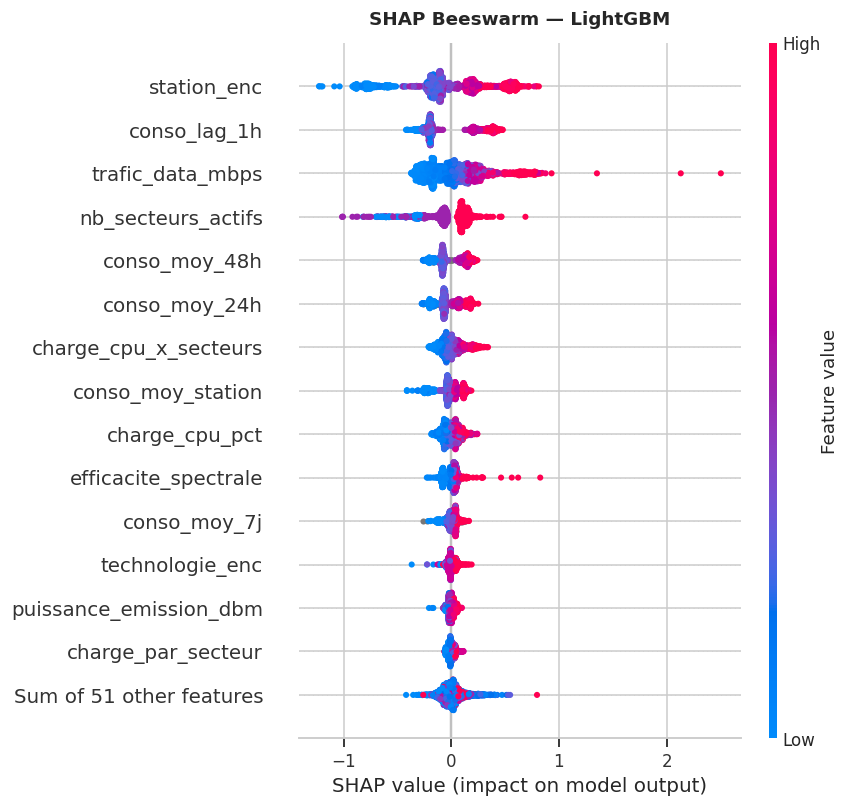

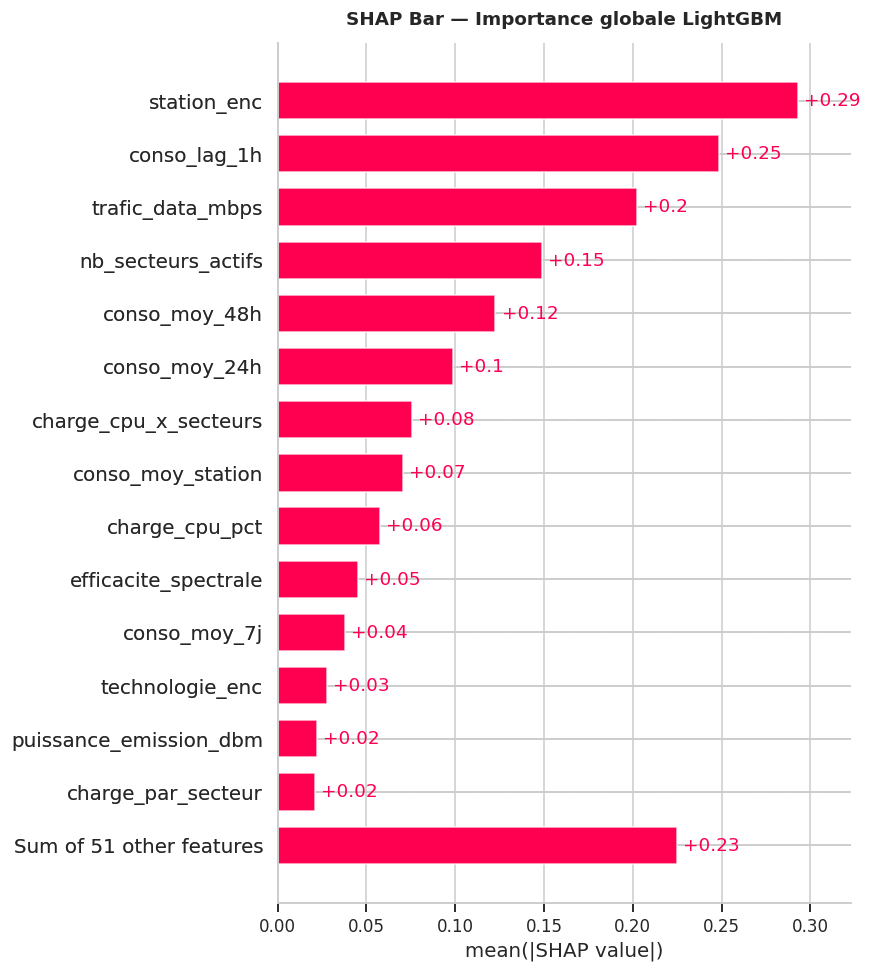

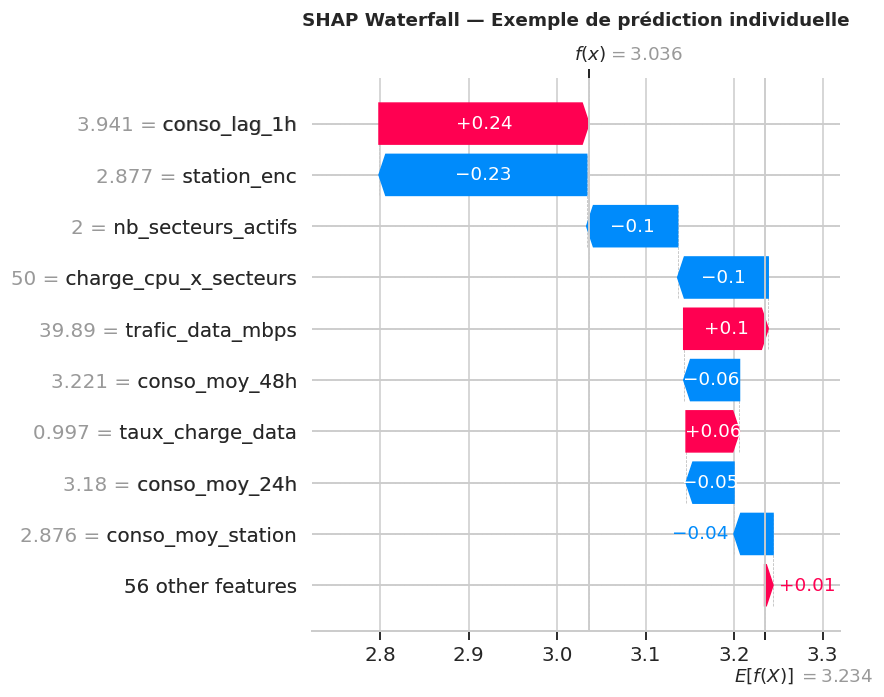


Top 3 features (contribution SHAP moyenne) :
  station_enc                    : 0.2929 kWh
  conso_lag_1h                   : 0.2483 kWh
  trafic_data_mbps               : 0.2025 kWh


In [50]:
# Cellule 12 — Interprétabilité SHAP

print('SHAP — LightGBM')

N_SHAP   = min(2000, len(X_test))
idx_shap = np.random.RandomState(42).choice(len(X_test), N_SHAP, replace=False)
X_shap   = X_test[idx_shap]

explainer   = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_shap)

ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    ev = float(np.array(ev).ravel()[0])
else:
    ev = float(ev)

explanation = shap.Explanation(
    values        = shap_values,
    base_values   = np.full(N_SHAP, ev),
    data          = X_shap,
    feature_names = FEATURES_V2,
)

# 1. Beeswarm — impact de chaque feature
shap.plots.beeswarm(explanation, max_display=15, show=False)
plt.title('SHAP Beeswarm — LightGBM', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/shap_beeswarm.png', dpi=110, bbox_inches='tight')
plt.show(); plt.close()

# 2. Bar — importance moyenne globale
shap.plots.bar(explanation, max_display=15, show=False)
plt.title('SHAP Bar — Importance globale LightGBM', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/shap_bar.png', dpi=110, bbox_inches='tight')
plt.show(); plt.close()

# 3. Waterfall — décomposition d'une prédiction individuelle
shap.plots.waterfall(explanation[0], show=False)
plt.title('SHAP Waterfall — Exemple de prédiction individuelle', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/shap_waterfall.png', dpi=110, bbox_inches='tight')
plt.show(); plt.close()

# Top 3 features SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3 = pd.Series(mean_abs_shap, index=FEATURES_V2).nlargest(3)
print('\nTop 3 features (contribution SHAP moyenne) :')
for f, v in top3.items():
    print(f'  {f:<30} : {v:.4f} kWh')

In [51]:
# Cellule 13 — Sauvegarde de tous les artefacts

# Modèle retenu : LightGBM (meilleur R² parmi les 7 modèles comparés)
best_model = gb
modele_nom = 'LightGBM'

# 1. Prédictions sur tout le dataset
df_pred_input = df[FEATURES_V2].copy()
for col in df_pred_input.columns:
    if df_pred_input[col].isna().any():
        df_pred_input[col] = df_pred_input[col].fillna(df_pred_input[col].median())

df['conso_predite'] = best_model.predict(df_pred_input.values)

# 2. Prédictions quantile
df['pred_q10'] = gb_q10.predict(df_pred_input.values)
df['pred_q90'] = gb_q90.predict(df_pred_input.values)

df['hors_intervalle'] = (
    (df['consommation_kwh'] < df['pred_q10']) |
    (df['consommation_kwh'] > df['pred_q90'])
).astype(int)
df['ecart_pct'] = (
    (df['consommation_kwh'] - df['conso_predite'])
    / df['conso_predite'].clip(lower=0.1) * 100
)

# 3. Sauvegarde modèles
joblib.dump(best_model, 'outputs/best_model.joblib', compress=3)

joblib.dump({
    'modele'  : gb,
    'features': FEATURES_V2,
}, 'outputs/modele_lgbm.joblib', compress=3)

joblib.dump({
    'technologie'    : le_tech,
    'type_zone'      : le_zone,
    'gouvernorat'    : le_gov,
    'station_enc_map': station_enc_map,
}, 'outputs/encodeurs.joblib', compress=3)

joblib.dump(
    {'q10': gb_q10, 'q90': gb_q90},
    'outputs/quantile_models.joblib', compress=3
)

joblib.dump({
    'features'              : FEATURES_V2,
    'target'                : TARGET,
    'modele_nom'            : modele_nom,
    'qos_seuil_optimisation': QOS_SEUIL_OPTIMISATION,
    'qos_cols'              : ['taux_charge_voix', 'taux_charge_data', 'stress_radio',
                               'score_qualite_radio', 'score_qos', 'classe_qos',
                               'optimisation_qos_autorisee'],
    'best_model_type'       : type(best_model).__name__,
}, 'outputs/config.joblib', compress=3)

# 4. Sauvegarde données
df[df['annee'] < 2024].to_parquet('outputs/df_train_processed.parquet', index=False)
df[df['annee'] == 2024].to_parquet('outputs/df_test_processed.parquet',  index=False)
df.to_parquet('outputs/df_full_processed.parquet', index=False)

with open('outputs/resultats_modeles.json', 'w') as f:
    json.dump(resultats_modeles, f, indent=2)

print('Tous les artefacts sauvegardés dans outputs/')
print(f'  - best_model.joblib       ({type(best_model).__name__})')
print('  - modele_lgbm.joblib')
print('  - encodeurs.joblib')
print('  - quantile_models.joblib')
print('  - config.joblib')
print('  - df_train / df_test / df_full processed.parquet')
print('  - resultats_modeles.json')

Tous les artefacts sauvegardés dans outputs/
  - best_model.joblib       (LGBMRegressor)
  - modele_lgbm.joblib
  - encodeurs.joblib
  - quantile_models.joblib
  - config.joblib
  - df_train / df_test / df_full processed.parquet
  - resultats_modeles.json


In [52]:
# Cellule 13b — RÉCAPITULATIF FINAL 

from datetime import datetime

# Variables de synthèse issues des cellules précédentes
r2_best       = r2_gb
rmse_pct_best = resultats_modeles['LightGBM']['rmse_pct']
mae_best      = resultats_modeles['LightGBM']['mae']

print('  RÉCAPITULATIF FINAL — NOTEBOOK 1 — APPRENTISSAGE SUPERVISÉ')
print(f'  Généré le {datetime.now().strftime("%Y-%m-%d %H:%M")}')

print('\n  DATASET')
print(f'    Train 2022–2023 : {len(df[df["annee"] < 2024]):>12,} lignes')
print(f'    Test  2024      : {len(df[df["annee"] == 2024]):>12,} lignes')
print(f'    Features V2     : {len(FEATURES_V2):>12} features')

print('\n  COMPARAISON DES 7 MODÈLES (test 2024)')
print(f'  {"Modèle":<26} {"R²":>8}  {"MAE":>8}  {"RMSE%":>8}  {"KPI ≥0.80":>10}')
print('  ' + '-' * 65)
for nom, res in sorted(resultats_modeles.items(), key=lambda x: -x[1]['r2']):
    kpi = 'ATTEINT' if res['r2'] >= 0.80 else 'MANQUÉ'
    print(f'  {nom:<26} {res["r2"]:>8.4f}  {res["mae"]:>8.4f}  '
          f'{res["rmse_pct"]:>7.1f}%  {kpi:>10}')

print('\n  MODÈLE RETENU')
print(f'    Nom             : {modele_nom}')
print(f'    R²              : {r2_best:.4f}')
print(f'    RMSE relative   : {rmse_pct_best:.1f}%')
print(f'    MAE             : {mae_best:.4f} kWh')

print('\n  KPI PROJET')
kpi_r2   = 'ATTEINT' if r2_best >= 0.80 else 'MANQUÉ'
kpi_rmse = 'ATTEINT' if rmse_pct_best <= 20 else 'MANQUÉ'
print(f'    R² ≥ 0.80       : {r2_best:.4f}  → {kpi_r2}')
print(f'    RMSE ≤ 20%      : {rmse_pct_best:.1f}%   → {kpi_rmse}')

print('\n  VALIDATION CROISÉE (TimeSeriesSplit, 5 folds, gap=24h)')
print(f'    R² moyen        : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}')
print(f'    RMSE moyenne    : {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f} kWh')

print('\n  INTERVALLES DE PRÉDICTION (Q10 / Q90)')
print(f'    Couverture      : {couverture:.1f}%  (cible théorique = 80%)')
print(f'    Largeur moyenne : {(y_pred_q90 - y_pred_q10).mean():.3f} kWh')

print('\n  TOP 3 FEATURES (SHAP)')
for f, v in top3.sort_values(ascending=False).head(3).items():
    print(f'    {f:<30} : {v:.4f} kWh contribution moyenne')

print('\n  ARTEFACTS SAUVEGARDÉS')
import os
for f in sorted(os.listdir('outputs')):
    taille = os.path.getsize(f'outputs/{f}') / 1024
    print(f'    outputs/{f:<35} {taille:>8.1f} Ko')

  RÉCAPITULATIF FINAL — NOTEBOOK 1 — APPRENTISSAGE SUPERVISÉ
  Généré le 2026-05-20 17:15

  DATASET
    Train 2022–2023 :    1,051,315 lignes
    Test  2024      :      525,706 lignes
    Features V2     :           65 features

  COMPARAISON DES 7 MODÈLES (test 2024)
  Modèle                           R²       MAE     RMSE%   KPI ≥0.80
  -----------------------------------------------------------------
  LightGBM                     0.8010    0.2504     19.8%     ATTEINT
  Extra Trees                  0.8009    0.2519     19.9%     ATTEINT
  Random Forest                0.8007    0.2519     19.9%     ATTEINT
  XGBoost                      0.8005    0.2506     19.9%     ATTEINT
  Gradient Boosting            0.8002    0.2525     19.9%     ATTEINT
  Ridge Regression             0.6956    0.4010     24.5%      MANQUÉ
  Régression Linéaire          0.6955    0.4011     24.5%      MANQUÉ
  Baseline Persistance         0.4664    0.5154     32.5%      MANQUÉ

  MODÈLE RETENU
    Nom        